<a href="https://colab.research.google.com/github/JesmirData/Butterfly2.0/blob/main/Estudio_Pozos_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ALCANCE DEL ESTUDIO: Utilizarregresión lineal de producción petrolera acumulada en seis meses por pozo, apoyada por regresión logística para el riesgo de baja productividad y KNN para mostrar comparables. La primera etapa en Colab sería construir una fila por pozo, unirla por idpozo con sus seis meses posteriores y revisar por qué faltan meses en otros pozos. Después dividiríamos por fecha y entrenaríamos los modelos sin usar información futura; esa precaución es esencial en datos temporales

In [1]:
# PASO 1 — Conectar Google Drive y verificar los archivos del ejercicio

from pathlib import Path

import pandas as pd
from google.colab import drive
from IPython.display import display

# 1. Conectar Google Drive
drive.mount("/content/drive")

# 2. Carpeta que contiene los cuatro CSV
CARPETA_DATOS = Path("/content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Utilizados")

# 3. Usar una sola copia de cada fuente anual
ARCHIVOS = {
    "fracturas": "datos-de-fractura-de-p.csv",
    "produccion_2023": "produccin-de-pozos-de-gas-y-petrleo-2023.csv",
    "produccion_2024": "produccin-de-pozo.csv",
    "produccion_2025": "produccin-de-pozos-de-gas-y-petrle.csv",
}

COLUMNAS_REQUERIDAS = {
    "fracturas": {
        "idpozo",
        "empresa_informante",
        "fecha_fin_fractura",
        "cantidad_fracturas",
        "longitud_rama_horizontal_m",
        "arena_bombeada_nacional_tn",
        "arena_bombeada_importada_tn",
        "agua_inyectada_m3",
        "formacion_productiva",
    },
    "produccion_2023": {
        "idpozo", "idempresa", "anio", "mes",
        "prod_pet", "provincia", "areapermisoconcesion",
    },
    "produccion_2024": {
        "idpozo", "idempresa", "anio", "mes",
        "prod_pet", "provincia", "areapermisoconcesion",
    },
    "produccion_2025": {
        "idpozo", "idempresa", "anio", "mes",
        "prod_pet", "provincia", "areapermisoconcesion",
    },
}

if not CARPETA_DATOS.is_dir():
    raise FileNotFoundError(
        f"No encuentro la carpeta: {CARPETA_DATOS}\n"
        "Crea YPF_ML/datos dentro de Mi unidad y sube allí los cuatro CSV."
    )

RUTAS = {
    clave: CARPETA_DATOS / nombre
    for clave, nombre in ARCHIVOS.items()
}

faltantes = [
    ruta.name
    for ruta in RUTAS.values()
    if not ruta.is_file()
]

if faltantes:
    disponibles = sorted(
        archivo.name
        for archivo in CARPETA_DATOS.iterdir()
        if archivo.is_file()
    )

    raise FileNotFoundError(
        "Faltan estos archivos:\n"
        + "\n".join(f"  - {nombre}" for nombre in faltantes)
        + "\n\nArchivos que sí encontré:\n"
        + (
            "\n".join(f"  - {nombre}" for nombre in disponibles)
            if disponibles
            else "  - Ninguno"
        )
    )

print("VERIFICACIÓN DE ARCHIVOS\n")

for clave, ruta in RUTAS.items():
    # Leer únicamente el encabezado y dos filas.
    muestra = pd.read_csv(
        ruta,
        nrows=2,
        encoding="utf-8-sig",
        low_memory=False,
    )

    columnas_faltantes = COLUMNAS_REQUERIDAS[clave] - set(muestra.columns)

    if columnas_faltantes:
        raise ValueError(
            f"El archivo {ruta.name} no contiene estas columnas necesarias: "
            f"{sorted(columnas_faltantes)}"
        )

    tamano_mib = ruta.stat().st_size / (1024 ** 2)

    if clave == "fracturas":
        columnas_visibles = [
            "idpozo",
            "empresa_informante",
            "fecha_fin_fractura",
            "cantidad_fracturas",
            "formacion_productiva",
        ]
    else:
        columnas_visibles = [
            "anio",
            "mes",
            "idpozo",
            "idempresa",
            "provincia",
            "prod_pet",
        ]

    print(f"Fuente: {clave}")
    print(f"Archivo: {ruta.name}")
    print(f"Tamaño: {tamano_mib:,.1f} MiB")
    print(f"Columnas encontradas: {len(muestra.columns)}")
    display(muestra[columnas_visibles])
    print()

print("PASO 1 COMPLETADO: los cuatro CSV existen y contienen las columnas necesarias.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
VERIFICACIÓN DE ARCHIVOS

Fuente: fracturas
Archivo: datos-de-fractura-de-p.csv
Tamaño: 1.2 MiB
Columnas encontradas: 30


,idpozo,empresa_informante,fecha_fin_fractura,cantidad_fracturas,formacion_productiva
0,159910,CAPEX S.A.,2019-04-30,3,los molles
1,159910,CAPEX S.A.,2018-11-03,1,los molles



Fuente: produccion_2023
Archivo: produccin-de-pozos-de-gas-y-petrleo-2023.csv
Tamaño: 290.6 MiB
Columnas encontradas: 38


,anio,mes,idpozo,idempresa,provincia,prod_pet
0,2023,1,145604,Z001,Rio Negro,0
1,2023,1,145624,Z001,Rio Negro,0



Fuente: produccion_2024
Archivo: produccin-de-pozo.csv
Tamaño: 305.1 MiB
Columnas encontradas: 39


,anio,mes,idpozo,idempresa,provincia,prod_pet
0,2024,1,145604,Z001,Rio Negro,0
1,2024,1,145617,Z001,Rio Negro,0



Fuente: produccion_2025
Archivo: produccin-de-pozos-de-gas-y-petrle.csv
Tamaño: 300.8 MiB
Columnas encontradas: 38


,anio,mes,idpozo,idempresa,provincia,prod_pet
0,2025,1,145622,Z001,Rio Negro,0
1,2025,1,145623,Z001,Rio Negro,0



PASO 1 COMPLETADO: los cuatro CSV existen y contienen las columnas necesarias.


In [3]:
# PASO 2 — Limpiar y verificar las fracturas de YPF

from pathlib import Path

import pandas as pd
from IPython.display import display

# Ruta real de tus archivos en Google Drive
CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)

# Carpeta de salida:
# .../Proyecto YPF_ML/Datos/Datos_Procesados
CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"

RUTA_ENTRADA = CARPETA_DATOS / "datos-de-fractura-de-p.csv"
RUTA_SALIDA = (
    CARPETA_PROCESADOS / "fracturas_ypf_2023_2025_h1.csv"
)

if not CARPETA_DATOS.is_dir():
    raise FileNotFoundError(
        f"No encuentro la carpeta de datos:\n{CARPETA_DATOS}"
    )

if not RUTA_ENTRADA.is_file():
    disponibles = sorted(
        archivo.name
        for archivo in CARPETA_DATOS.iterdir()
        if archivo.is_file()
    )

    raise FileNotFoundError(
        f"No encuentro el archivo:\n{RUTA_ENTRADA}\n\n"
        "Archivos encontrados en la carpeta:\n"
        + (
            "\n".join(f"  - {nombre}" for nombre in disponibles)
            if disponibles
            else "  - Ninguno"
        )
    )

COLUMNAS = [
    "id_base_fractura_adjiv",
    "idpozo",
    "sigla",
    "empresa_informante",
    "areapermisoconcesion",
    "yacimiento",
    "formacion_productiva",
    "tipo_reservorio",
    "subtipo_reservorio",
    "longitud_rama_horizontal_m",
    "cantidad_fracturas",
    "arena_bombeada_nacional_tn",
    "arena_bombeada_importada_tn",
    "agua_inyectada_m3",
    "presion_maxima_psi",
    "fecha_inicio_fractura",
    "fecha_fin_fractura",
    "fecha_data",
]

COLUMNAS_NUMERICAS = [
    "longitud_rama_horizontal_m",
    "cantidad_fracturas",
    "arena_bombeada_nacional_tn",
    "arena_bombeada_importada_tn",
    "agua_inyectada_m3",
    "presion_maxima_psi",
]

# 1. Leer únicamente las columnas necesarias.
# idpozo se mantiene como texto porque es un identificador.
fracturas = pd.read_csv(
    RUTA_ENTRADA,
    usecols=COLUMNAS,
    dtype={
        "idpozo": "string",
        "id_base_fractura_adjiv": "string",
    },
    encoding="utf-8-sig",
    low_memory=False,
)

# 2. Normalizar textos.
fracturas["idpozo"] = fracturas["idpozo"].str.strip()

for columna in [
    "empresa_informante",
    "areapermisoconcesion",
    "yacimiento",
    "formacion_productiva",
    "tipo_reservorio",
    "subtipo_reservorio",
]:
    fracturas[columna] = (
        fracturas[columna]
        .astype("string")
        .str.strip()
        .str.upper()
    )

# 3. Convertir fechas.
for columna in [
    "fecha_inicio_fractura",
    "fecha_fin_fractura",
    "fecha_data",
]:
    fracturas[columna] = pd.to_datetime(
        fracturas[columna],
        errors="coerce",
    )

# 4. Seleccionar los registros informados por YPF.
fracturas_ypf = fracturas.loc[
    fracturas["empresa_informante"].eq("YPF S.A.")
].copy()

print(f"Registros totales de fractura: {len(fracturas):,}")
print(f"Registros informados por YPF: {len(fracturas_ypf):,}")

# Evitar que se excluyan silenciosamente registros sin fecha.
sin_fecha_fin = int(
    fracturas_ypf["fecha_fin_fractura"].isna().sum()
)

if sin_fecha_fin:
    raise ValueError(
        f"Hay {sin_fecha_fin} registros de YPF sin una "
        "fecha_fin_fractura válida."
    )

# 5. Conservar fracturas terminadas entre enero de 2023
# y junio de 2025.
fracturas_ypf = fracturas_ypf.loc[
    fracturas_ypf["fecha_fin_fractura"].between(
        "2023-01-01",
        "2025-06-30",
    )
].copy()

# 6. Convertir variables numéricas.
for columna in COLUMNAS_NUMERICAS:
    fracturas_ypf[columna] = pd.to_numeric(
        fracturas_ypf[columna],
        errors="coerce",
    )

# 7. Verificar calidad antes de guardar.
sin_id = int(
    fracturas_ypf["idpozo"].fillna("").eq("").sum()
)

fechas_inicio_invalidas = int(
    fracturas_ypf["fecha_inicio_fractura"].isna().sum()
)

fechas_invertidas = int(
    (
        fracturas_ypf["fecha_fin_fractura"]
        < fracturas_ypf["fecha_inicio_fractura"]
    ).sum()
)

pozos_repetidos = int(
    fracturas_ypf["idpozo"].duplicated().sum()
)

numericos_faltantes = (
    fracturas_ypf[COLUMNAS_NUMERICAS]
    .isna()
    .sum()
)

numericos_negativos = (
    fracturas_ypf[COLUMNAS_NUMERICAS]
    .lt(0)
    .sum()
)

fracturas_no_positivas = int(
    fracturas_ypf["cantidad_fracturas"].le(0).sum()
)

print("\nCONTROL DE CALIDAD")
print(f"Fracturas seleccionadas: {len(fracturas_ypf):,}")
print(f"Pozos únicos: {fracturas_ypf['idpozo'].nunique():,}")
print(f"Identificadores vacíos: {sin_id}")
print(f"Fechas de inicio inválidas: {fechas_inicio_invalidas}")
print(f"Fechas invertidas: {fechas_invertidas}")
print(f"Identificadores de pozo repetidos: {pozos_repetidos}")
print(f"Cantidad de fracturas no positiva: {fracturas_no_positivas}")

print("\nValores numéricos faltantes:")
print(numericos_faltantes.to_string())

print("\nValores numéricos negativos:")
print(numericos_negativos.to_string())

if (
    sin_id
    or fechas_inicio_invalidas
    or fechas_invertidas
    or pozos_repetidos
    or fracturas_no_positivas
    or numericos_faltantes.sum()
    or numericos_negativos.sum()
):
    raise ValueError(
        "La tabla presenta problemas de calidad. "
        "Revisa el control anterior antes de continuar."
    )

# Informar longitudes iguales a cero sin modificarlas.
longitud_cero = int(
    fracturas_ypf["longitud_rama_horizontal_m"].eq(0).sum()
)

print(
    "\nPozos con longitud horizontal igual a cero: "
    f"{longitud_cero}"
)

print("\nFRACTURAS POR AÑO DE FINALIZACIÓN")
print(
    fracturas_ypf["fecha_fin_fractura"]
    .dt.year
    .value_counts()
    .sort_index()
    .to_string()
)

# 8. Ordenar y guardar.
fracturas_ypf = (
    fracturas_ypf
    .sort_values(["fecha_fin_fractura", "idpozo"])
    .reset_index(drop=True)
)

CARPETA_PROCESADOS.mkdir(
    parents=True,
    exist_ok=True,
)

fracturas_ypf.to_csv(
    RUTA_SALIDA,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d",
)

print("\nPRIMERAS CINCO FILAS PREPARADAS")
display(
    fracturas_ypf[
        [
            "idpozo",
            "fecha_fin_fractura",
            "areapermisoconcesion",
            "formacion_productiva",
            "cantidad_fracturas",
            "longitud_rama_horizontal_m",
            "agua_inyectada_m3",
        ]
    ].head()
)

print(f"\nArchivo guardado: {RUTA_SALIDA}")
print("PASO 2 COMPLETADO")

Registros totales de fractura: 4,910
Registros informados por YPF: 2,225

CONTROL DE CALIDAD
Fracturas seleccionadas: 471
Pozos únicos: 471
Identificadores vacíos: 0
Fechas de inicio inválidas: 0
Fechas invertidas: 0
Identificadores de pozo repetidos: 0
Cantidad de fracturas no positiva: 0

Valores numéricos faltantes:
longitud_rama_horizontal_m     0
cantidad_fracturas             0
arena_bombeada_nacional_tn     0
arena_bombeada_importada_tn    0
agua_inyectada_m3              0
presion_maxima_psi             0

Valores numéricos negativos:
longitud_rama_horizontal_m     0
cantidad_fracturas             0
arena_bombeada_nacional_tn     0
arena_bombeada_importada_tn    0
agua_inyectada_m3              0
presion_maxima_psi             0

Pozos con longitud horizontal igual a cero: 24

FRACTURAS POR AÑO DE FINALIZACIÓN
fecha_fin_fractura
2023    166
2024    182
2025    123

PRIMERAS CINCO FILAS PREPARADAS


,idpozo,fecha_fin_fractura,areapermisoconcesion,formacion_productiva,cantidad_fracturas,longitud_rama_horizontal_m,agua_inyectada_m3
0,164578,2023-01-07,LOMA AMARILLA SUR,VACA MUERTA,33,2437.0,46533.15
1,164577,2023-01-08,LOMA AMARILLA SUR,VACA MUERTA,41,2477.0,57379.31
2,163955,2023-01-11,RIO NEUQUEN,PUNTA ROSADA,14,0.0,6979.57
3,164028,2023-01-17,LOMA CAMPANA,VACA MUERTA,24,1611.0,34419.44
4,164030,2023-01-17,LOMA CAMPANA,VACA MUERTA,26,1624.0,36129.11



Archivo guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/fracturas_ypf_2023_2025_h1.csv
PASO 2 COMPLETADO


In [4]:
# PASO 3 — Extraer producción mensual de los pozos fracturados por YPF

from pathlib import Path

import pandas as pd
from IPython.display import display

CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)

CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"

RUTA_FRACTURAS = (
    CARPETA_PROCESADOS / "fracturas_ypf_2023_2025_h1.csv"
)

RUTA_SALIDA = (
    CARPETA_PROCESADOS
    / "produccion_mensual_pozos_ypf_2023_2025.csv"
)

ARCHIVOS_PRODUCCION = {
    2023: "produccin-de-pozos-de-gas-y-petrleo-2023.csv",
    2024: "produccin-de-pozo.csv",
    2025: "produccin-de-pozos-de-gas-y-petrle.csv",
}

COLUMNAS_PRODUCCION = [
    "idpozo",
    "idempresa",
    "anio",
    "mes",
    "prod_pet",
    "prod_gas",
    "provincia",
    "areapermisoconcesion",
    "rectificado",
]

# 1. Verificar entradas.
if not RUTA_FRACTURAS.is_file():
    raise FileNotFoundError(
        f"No encuentro el resultado del Paso 2:\n{RUTA_FRACTURAS}"
    )

for anio_archivo, nombre in ARCHIVOS_PRODUCCION.items():
    ruta = CARPETA_DATOS / nombre

    if not ruta.is_file():
        raise FileNotFoundError(
            f"No encuentro el archivo de {anio_archivo}:\n{ruta}"
        )

# 2. Leer los identificadores preparados en el Paso 2.
fracturas_ypf = pd.read_csv(
    RUTA_FRACTURAS,
    usecols=["idpozo"],
    dtype={"idpozo": "string"},
    encoding="utf-8-sig",
)

fracturas_ypf["idpozo"] = fracturas_ypf["idpozo"].str.strip()

if fracturas_ypf["idpozo"].isna().any():
    raise ValueError(
        "El archivo de fracturas contiene identificadores vacíos."
    )

if fracturas_ypf["idpozo"].duplicated().any():
    raise ValueError(
        "El archivo de fracturas contiene pozos repetidos."
    )

ids_objetivo = set(fracturas_ypf["idpozo"])

print(f"Pozos de YPF que buscamos: {len(ids_objetivo):,}")
print("Leyendo producción por bloques...\n")

# 3. Recorrer un año a la vez, sin cargar cada CSV completo.
bloques_seleccionados = []

for anio_archivo, nombre_archivo in ARCHIVOS_PRODUCCION.items():
    ruta = CARPETA_DATOS / nombre_archivo

    filas_leidas = 0
    filas_de_pozos_objetivo = 0
    filas_otros_operadores = 0
    filas_ypf = 0

    lector = pd.read_csv(
        ruta,
        usecols=COLUMNAS_PRODUCCION,
        dtype={
            "idpozo": "string",
            "idempresa": "string",
        },
        encoding="utf-8-sig",
        chunksize=100_000,
        low_memory=False,
    )

    for bloque in lector:
        filas_leidas += len(bloque)

        bloque["idpozo"] = bloque["idpozo"].str.strip()
        bloque["idempresa"] = (
            bloque["idempresa"]
            .str.strip()
            .str.upper()
        )

        # Conservar únicamente los pozos del Paso 2.
        seleccion = bloque.loc[
            bloque["idpozo"].isin(ids_objetivo)
        ].copy()

        filas_de_pozos_objetivo += len(seleccion)

        # Identificar cambios o diferencias de operador.
        filas_otros_operadores += int(
            seleccion["idempresa"].ne("YPF").fillna(True).sum()
        )

        seleccion = seleccion.loc[
            seleccion["idempresa"].eq("YPF")
        ].copy()

        if seleccion.empty:
            continue

        # Convertir y validar los valores que usaremos.
        for columna in ["anio", "mes", "prod_pet", "prod_gas"]:
            seleccion[columna] = pd.to_numeric(
                seleccion[columna],
                errors="coerce",
            )

        if seleccion[["anio", "mes", "prod_pet"]].isna().any().any():
            raise ValueError(
                f"Hay año, mes o prod_pet inválidos en "
                f"{nombre_archivo}."
            )

        if not seleccion["anio"].eq(anio_archivo).all():
            raise ValueError(
                f"Encontré registros con un año distinto de "
                f"{anio_archivo} en {nombre_archivo}."
            )

        if not seleccion["mes"].between(1, 12).all():
            raise ValueError(
                f"Encontré meses fuera del rango 1–12 en "
                f"{nombre_archivo}."
            )

        if seleccion["prod_pet"].lt(0).any():
            raise ValueError(
                f"Encontré prod_pet negativo para un pozo "
                f"seleccionado en {nombre_archivo}. "
                "Debemos revisar ese registro antes de agregarlo."
            )

        seleccion["anio"] = seleccion["anio"].astype("int64")
        seleccion["mes"] = seleccion["mes"].astype("int64")
        seleccion["archivo_origen"] = nombre_archivo

        bloques_seleccionados.append(seleccion)
        filas_ypf += len(seleccion)

    print(f"Año {anio_archivo}")
    print(f"  Filas leídas: {filas_leidas:,}")
    print(f"  Filas de los pozos buscados: "
          f"{filas_de_pozos_objetivo:,}")
    print(f"  Filas atribuidas a otros operadores: "
          f"{filas_otros_operadores:,}")
    print(f"  Filas seleccionadas de YPF: {filas_ypf:,}")
    print()

if not bloques_seleccionados:
    raise ValueError(
        "No encontré producción de YPF para los pozos seleccionados."
    )

# 4. Unir solo los bloques pequeños que pasaron los controles.
produccion_ypf = pd.concat(
    bloques_seleccionados,
    ignore_index=True,
)

duplicados = produccion_ypf.duplicated(
    subset=["idpozo", "anio", "mes"],
    keep=False,
)

if duplicados.any():
    print("Ejemplos de claves pozo–mes duplicadas:")
    display(
        produccion_ypf.loc[
            duplicados,
            ["idpozo", "anio", "mes", "prod_pet", "archivo_origen"],
        ].head(10)
    )

    raise ValueError(
        "Hay registros duplicados de idpozo–anio–mes. "
        "No guardaré la tabla hasta resolverlos."
    )

# 5. Crear la fecha del mes, ordenar y revisar cobertura.
produccion_ypf["fecha_mes"] = pd.to_datetime(
    {
        "year": produccion_ypf["anio"],
        "month": produccion_ypf["mes"],
        "day": 1,
    }
)

produccion_ypf = (
    produccion_ypf
    .sort_values(["fecha_mes", "idpozo"])
    .reset_index(drop=True)
)

resumen = (
    produccion_ypf
    .groupby("anio")
    .agg(
        registros=("idpozo", "size"),
        pozos_unicos=("idpozo", "nunique"),
        meses_con_petroleo=("prod_pet", lambda x: int(x.gt(0).sum())),
        volumen_petroleo_m3=("prod_pet", "sum"),
    )
)

pozos_encontrados = produccion_ypf["idpozo"].nunique()
pozos_sin_registros = len(
    ids_objetivo - set(produccion_ypf["idpozo"])
)

print("COBERTURA DE PRODUCCIÓN")
display(resumen)

print("REGISTROS POR PROVINCIA")
display(
    produccion_ypf
    .groupby(["anio", "provincia"])
    .size()
    .rename("registros")
    .reset_index()
)

print(f"Pozos únicos encontrados: {pozos_encontrados:,}")
print(f"Pozos sin registros en 2023–2025: "
      f"{pozos_sin_registros:,}")
print(f"Claves pozo–mes duplicadas: "
      f"{int(duplicados.sum()):,}")

# 6. Guardar la tabla mensual seleccionada.
CARPETA_PROCESADOS.mkdir(
    parents=True,
    exist_ok=True,
)

produccion_ypf.to_csv(
    RUTA_SALIDA,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d",
)

print("\nPRIMERAS CINCO FILAS")
display(
    produccion_ypf[
        [
            "idpozo",
            "fecha_mes",
            "provincia",
            "areapermisoconcesion",
            "prod_pet",
        ]
    ].head()
)

print(f"\nArchivo guardado: {RUTA_SALIDA}")
print("PASO 3 COMPLETADO")

Pozos de YPF que buscamos: 471
Leyendo producción por bloques...

Año 2023
  Filas leídas: 974,971
  Filas de los pozos buscados: 775
  Filas atribuidas a otros operadores: 0
  Filas seleccionadas de YPF: 775

Año 2024
  Filas leídas: 983,551
  Filas de los pozos buscados: 2,943
  Filas atribuidas a otros operadores: 0
  Filas seleccionadas de YPF: 2,943

Año 2025
  Filas leídas: 991,936
  Filas de los pozos buscados: 5,201
  Filas atribuidas a otros operadores: 0
  Filas seleccionadas de YPF: 5,201

COBERTURA DE PRODUCCIÓN


,registros,pozos_unicos,meses_con_petroleo,volumen_petroleo_m3
anio,,,,
2023,775,143,723,2067034.21
2024,2943,331,2806,6957058.96
2025,5201,471,4916,10266011.05


REGISTROS POR PROVINCIA


,anio,provincia,registros
0,2023,Neuquén,775
1,2024,Mendoza,22
2,2024,Neuquén,2921
3,2025,Mendoza,24
4,2025,Neuquén,5177


Pozos únicos encontrados: 471
Pozos sin registros en 2023–2025: 0
Claves pozo–mes duplicadas: 0

PRIMERAS CINCO FILAS


,idpozo,fecha_mes,provincia,areapermisoconcesion,prod_pet
0,162777,2023-01-01,Neuquén,EL OREJANO,0.00
1,162778,2023-01-01,Neuquén,EL OREJANO,0.00
2,162779,2023-01-01,Neuquén,EL OREJANO,0.00
3,163762,2023-01-01,Neuquén,BANDURRIA SUR,0.00
4,163955,2023-01-01,Neuquén,RIO NEUQUEN,177.65



Archivo guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/produccion_mensual_pozos_ypf_2023_2025.csv
PASO 3 COMPLETADO


In [5]:
# PASO 4 — Construir los seis meses posteriores a cada fractura

from pathlib import Path

import pandas as pd
from IPython.display import display

CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)

CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"

RUTA_FRACTURAS = (
    CARPETA_PROCESADOS / "fracturas_ypf_2023_2025_h1.csv"
)

RUTA_PRODUCCION = (
    CARPETA_PROCESADOS
    / "produccion_mensual_pozos_ypf_2023_2025.csv"
)

RUTA_CALENDARIO = (
    CARPETA_PROCESADOS
    / "calendario_6_meses_post_fractura.csv"
)

RUTA_OBJETIVO = (
    CARPETA_PROCESADOS
    / "pozos_ypf_objetivo_produccion_6_meses.csv"
)

for ruta in [RUTA_FRACTURAS, RUTA_PRODUCCION]:
    if not ruta.is_file():
        raise FileNotFoundError(f"No encuentro:\n{ruta}")

# 1. Leer las dos tablas pequeñas creadas en los pasos anteriores.
fracturas = pd.read_csv(
    RUTA_FRACTURAS,
    dtype={"idpozo": "string"},
    parse_dates=["fecha_fin_fractura"],
    encoding="utf-8-sig",
)

produccion = pd.read_csv(
    RUTA_PRODUCCION,
    dtype={"idpozo": "string"},
    parse_dates=["fecha_mes"],
    encoding="utf-8-sig",
)

fracturas["idpozo"] = fracturas["idpozo"].str.strip()
produccion["idpozo"] = produccion["idpozo"].str.strip()

produccion["prod_pet"] = pd.to_numeric(
    produccion["prod_pet"],
    errors="coerce",
)

if fracturas["idpozo"].isna().any():
    raise ValueError("Hay idpozo vacío en la tabla de fracturas.")

if fracturas["idpozo"].duplicated().any():
    raise ValueError("Hay pozos repetidos en la tabla de fracturas.")

if fracturas["fecha_fin_fractura"].isna().any():
    raise ValueError("Hay fechas de fractura inválidas.")

if produccion[["idpozo", "fecha_mes", "prod_pet"]].isna().any().any():
    raise ValueError(
        "Hay identificadores, meses o volúmenes inválidos "
        "en la tabla de producción."
    )

if produccion.duplicated(["idpozo", "fecha_mes"]).any():
    raise ValueError(
        "Hay registros repetidos para el mismo pozo y mes."
    )

# 2. Crear seis filas por pozo: meses 1, 2, 3, 4, 5 y 6
# posteriores al mes de finalización de la fractura.
columnas_calendario = [
    "idpozo",
    "fecha_fin_fractura",
]

partes_calendario = []

for mes_relativo in range(1, 7):
    parte = fracturas[columnas_calendario].copy()

    parte["mes_relativo"] = mes_relativo

    parte["fecha_mes"] = (
        parte["fecha_fin_fractura"]
        .dt.to_period("M")
        .add(mes_relativo)
        .dt.to_timestamp()
    )

    partes_calendario.append(parte)

calendario = pd.concat(
    partes_calendario,
    ignore_index=True,
)

if calendario["fecha_mes"].max() > pd.Timestamp("2025-12-01"):
    raise ValueError(
        "El calendario solicita producción posterior "
        "a diciembre de 2025."
    )

# 3. Unir cada mes esperado con la producción reportada.
# Una fila ausente NO se convierte en cero.
calendario = calendario.merge(
    produccion[
        [
            "idpozo",
            "fecha_mes",
            "prod_pet",
            "provincia",
        ]
    ],
    on=["idpozo", "fecha_mes"],
    how="left",
    validate="one_to_one",
    indicator=True,
)

calendario["registro_encontrado"] = (
    calendario["_merge"].eq("both")
)

calendario["estado_mes"] = "SIN_REGISTRO"

calendario.loc[
    calendario["registro_encontrado"]
    & calendario["prod_pet"].eq(0),
    "estado_mes",
] = "REGISTRADO_CERO"

calendario.loc[
    calendario["registro_encontrado"]
    & calendario["prod_pet"].gt(0),
    "estado_mes",
] = "REGISTRADO_POSITIVO"

calendario = calendario.drop(columns=["_merge"])

# 4. Resumir los seis meses para cada pozo.
resumen_6m = (
    calendario
    .groupby("idpozo", as_index=False)
    .agg(
        meses_reportados=(
            "registro_encontrado",
            "sum",
        ),
        meses_con_cero=(
            "estado_mes",
            lambda valores: int(
                valores.eq("REGISTRADO_CERO").sum()
            ),
        ),
        volumen_observado_m3=(
            "prod_pet",
            "sum",
        ),
    )
)

resumen_6m["meses_sin_registro"] = (
    6 - resumen_6m["meses_reportados"]
)

resumen_6m["cobertura_6_meses_completa"] = (
    resumen_6m["meses_reportados"].eq(6)
)

# El objetivo solo existe si están reportados los seis meses.
resumen_6m["produccion_6m_m3"] = (
    resumen_6m["volumen_observado_m3"]
    .where(
        resumen_6m["cobertura_6_meses_completa"]
    )
)

# 5. Conservar las características originales del pozo
# junto con su objetivo y sus indicadores de cobertura.
pozos_objetivo = fracturas.merge(
    resumen_6m,
    on="idpozo",
    how="left",
    validate="one_to_one",
)

if len(pozos_objetivo) != len(fracturas):
    raise ValueError(
        "La unión modificó inesperadamente la cantidad de pozos."
    )

if pozos_objetivo["meses_reportados"].isna().any():
    raise ValueError(
        "Algún pozo quedó sin calendario de seis meses."
    )

# 6. Ordenar, revisar y guardar ambas tablas.
calendario = (
    calendario
    .sort_values(["idpozo", "mes_relativo"])
    .reset_index(drop=True)
)

pozos_objetivo = (
    pozos_objetivo
    .sort_values(["fecha_fin_fractura", "idpozo"])
    .reset_index(drop=True)
)

CARPETA_PROCESADOS.mkdir(
    parents=True,
    exist_ok=True,
)

calendario.to_csv(
    RUTA_CALENDARIO,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d",
)

pozos_objetivo.to_csv(
    RUTA_OBJETIVO,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d",
)

print("CONTROL DEL OBJETIVO")
print(f"Pozos examinados: {len(pozos_objetivo):,}")
print(f"Meses esperados: {len(calendario):,}")

print("\nEstado de los meses esperados:")
print(calendario["estado_mes"].value_counts().to_string())

print(
    "\nPozos con los seis meses reportados: "
    f"{int(pozos_objetivo['cobertura_6_meses_completa'].sum()):,}"
)

print(
    "Pozos con uno o más meses sin registro: "
    f"{int((~pozos_objetivo['cobertura_6_meses_completa']).sum()):,}"
)

print("\nCOBERTURA POR AÑO DE FRACTURA")
cobertura_por_anio = (
    pozos_objetivo
    .assign(
        anio_fractura=lambda tabla:
            tabla["fecha_fin_fractura"].dt.year
    )
    .groupby("anio_fractura")
    .agg(
        pozos=("idpozo", "size"),
        objetivo_disponible=(
            "cobertura_6_meses_completa",
            "sum",
        ),
    )
)

display(cobertura_por_anio)

print("\nEJEMPLO DE LA TABLA POR POZO")
display(
    pozos_objetivo[
        [
            "idpozo",
            "fecha_fin_fractura",
            "cantidad_fracturas",
            "meses_reportados",
            "meses_sin_registro",
            "produccion_6m_m3",
        ]
    ].head(10)
)

print(f"\nCalendario guardado: {RUTA_CALENDARIO}")
print(f"Tabla por pozo guardada: {RUTA_OBJETIVO}")
print("PASO 4 COMPLETADO")

CONTROL DEL OBJETIVO
Pozos examinados: 471
Meses esperados: 2,826

Estado de los meses esperados:
estado_mes
REGISTRADO_POSITIVO    2557
SIN_REGISTRO            219
REGISTRADO_CERO          50

Pozos con los seis meses reportados: 352
Pozos con uno o más meses sin registro: 119

COBERTURA POR AÑO DE FRACTURA


,pozos,objetivo_disponible
anio_fractura,,
2023,166,87
2024,182,147
2025,123,118



EJEMPLO DE LA TABLA POR POZO


,idpozo,fecha_fin_fractura,cantidad_fracturas,meses_reportados,meses_sin_registro,produccion_6m_m3
0,164578,2023-01-07,33,0,6,NaN
1,164577,2023-01-08,41,0,6,NaN
2,163955,2023-01-11,14,6,0,1748.25
3,164028,2023-01-17,24,6,0,17710.72
4,164030,2023-01-17,26,6,0,17076.59
5,164114,2023-01-17,10,5,1,NaN
6,164027,2023-01-22,40,6,0,23019.18
7,164029,2023-01-22,35,6,0,18753.03
8,164031,2023-01-22,31,6,0,19229.47
9,164575,2023-01-23,37,0,6,NaN



Calendario guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/calendario_6_meses_post_fractura.csv
Tabla por pozo guardada: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/pozos_ypf_objetivo_produccion_6_meses.csv
PASO 4 COMPLETADO


In [6]:
# PASO 5 — Separar entrenamiento y prueba por fecha de fractura

from pathlib import Path

import pandas as pd
from IPython.display import display

CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)

CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"

RUTA_ENTRADA = (
    CARPETA_PROCESADOS
    / "pozos_ypf_objetivo_produccion_6_meses.csv"
)

RUTA_PARTICIONES = (
    CARPETA_PROCESADOS / "pozos_ypf_particiones_6m.csv"
)

RUTA_ENTRENAMIENTO = (
    CARPETA_PROCESADOS / "ypf_entrenamiento_6m.csv"
)

RUTA_PRUEBA = (
    CARPETA_PROCESADOS / "ypf_prueba_6m.csv"
)

if not RUTA_ENTRADA.is_file():
    raise FileNotFoundError(
        f"No encuentro el resultado del Paso 4:\n{RUTA_ENTRADA}"
    )

# 1. Leer la tabla de una fila por pozo.
datos = pd.read_csv(
    RUTA_ENTRADA,
    dtype={"idpozo": "string"},
    parse_dates=["fecha_fin_fractura"],
    encoding="utf-8-sig",
)

datos["idpozo"] = datos["idpozo"].str.strip()

for columna in [
    "meses_reportados",
    "meses_sin_registro",
    "produccion_6m_m3",
]:
    datos[columna] = pd.to_numeric(
        datos[columna],
        errors="coerce",
    )

if datos["idpozo"].isna().any():
    raise ValueError("Hay identificadores de pozo vacíos.")

if datos["idpozo"].duplicated().any():
    raise ValueError("Hay pozos duplicados.")

if datos["fecha_fin_fractura"].isna().any():
    raise ValueError("Hay fechas de fractura inválidas.")

if datos[["meses_reportados", "meses_sin_registro"]].isna().any().any():
    raise ValueError("Hay controles de cobertura inválidos.")

# 2. Volver a comprobar qué pozos tienen seis meses completos.
objetivo_completo = (
    datos["meses_reportados"].eq(6)
    & datos["meses_sin_registro"].eq(0)
)

if (
    objetivo_completo
    & datos["produccion_6m_m3"].isna()
).any():
    raise ValueError(
        "Hay pozos con seis meses reportados y objetivo vacío."
    )

if (
    ~objetivo_completo
    & datos["produccion_6m_m3"].notna()
).any():
    raise ValueError(
        "Hay pozos con meses faltantes y objetivo asignado."
    )

if datos.loc[
    objetivo_completo,
    "produccion_6m_m3",
].lt(0).any():
    raise ValueError("Hay objetivos de producción negativos.")

# 3. Calcular el último mes utilizado para construir cada objetivo.
datos["ultimo_mes_objetivo"] = (
    (
        datos["fecha_fin_fractura"].dt.to_period("M")
        + 6
    )
    .dt.to_timestamp()
)

# 4. Asignar cada pozo a un grupo.
datos["particion"] = "SIN_OBJETIVO"

entrenamiento = (
    objetivo_completo
    & datos["fecha_fin_fractura"].between(
        "2023-01-01",
        "2024-06-30",
    )
)

reserva_temporal = (
    objetivo_completo
    & datos["fecha_fin_fractura"].between(
        "2024-07-01",
        "2024-12-31",
    )
)

prueba = (
    objetivo_completo
    & datos["fecha_fin_fractura"].between(
        "2025-01-01",
        "2025-06-30",
    )
)

datos.loc[entrenamiento, "particion"] = "ENTRENAMIENTO"
datos.loc[reserva_temporal, "particion"] = "RESERVA_TEMPORAL"
datos.loc[prueba, "particion"] = "PRUEBA"

if (
    objetivo_completo
    & datos["particion"].eq("SIN_OBJETIVO")
).any():
    raise ValueError(
        "Hay pozos con objetivo completo sin partición asignada."
    )

# 5. Comprobar el orden temporal.
train = datos.loc[
    datos["particion"].eq("ENTRENAMIENTO")
].copy()

test = datos.loc[
    datos["particion"].eq("PRUEBA")
].copy()

if train.empty or test.empty:
    raise ValueError(
        "La división dejó vacío entrenamiento o prueba."
    )

if train["ultimo_mes_objetivo"].max() >= (
    test["fecha_fin_fractura"].min()
):
    raise ValueError(
        "Los resultados usados en entrenamiento alcanzan "
        "el período de las fracturas de prueba."
    )

if set(train["idpozo"]) & set(test["idpozo"]):
    raise ValueError(
        "Un mismo pozo aparece en entrenamiento y prueba."
    )

# 6. Definir desde ahora las columnas que podrán utilizar los modelos.
# idpozo, fecha y área quedan como metadatos para seguimiento.
# meses_reportados, volumen_observado_m3 y cobertura NO serán entradas.
METADATOS = [
    "idpozo",
    "fecha_fin_fractura",
    "areapermisoconcesion",
]

VARIABLES_NUMERICAS = [
    "longitud_rama_horizontal_m",
    "cantidad_fracturas",
    "arena_bombeada_nacional_tn",
    "arena_bombeada_importada_tn",
    "agua_inyectada_m3",
    "presion_maxima_psi",
]

VARIABLES_CATEGORICAS = [
    "formacion_productiva",
]

OBJETIVO = "produccion_6m_m3"

COLUMNAS_MODELO = (
    METADATOS
    + VARIABLES_NUMERICAS
    + VARIABLES_CATEGORICAS
    + [OBJETIVO]
)

faltantes = set(COLUMNAS_MODELO) - set(datos.columns)

if faltantes:
    raise ValueError(
        f"Faltan columnas para preparar el modelo: "
        f"{sorted(faltantes)}"
    )

# 7. Guardar trazabilidad completa y archivos separados.
CARPETA_PROCESADOS.mkdir(
    parents=True,
    exist_ok=True,
)

datos.to_csv(
    RUTA_PARTICIONES,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d",
)

train[COLUMNAS_MODELO].to_csv(
    RUTA_ENTRENAMIENTO,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d",
)

test[COLUMNAS_MODELO].to_csv(
    RUTA_PRUEBA,
    index=False,
    encoding="utf-8-sig",
    date_format="%Y-%m-%d",
)

# 8. Mostrar controles sin analizar todavía los resultados de prueba.
print("TAMAÑO DE LAS PARTICIONES")
print(datos["particion"].value_counts().to_string())

print("\nPARTICIONES POR AÑO DE FRACTURA")
display(
    pd.crosstab(
        datos["fecha_fin_fractura"].dt.year,
        datos["particion"],
    )
)

print("\nORDEN TEMPORAL")
print(
    "Última fractura de entrenamiento: "
    f"{train['fecha_fin_fractura'].max().date()}"
)
print(
    "Último mes usado en sus objetivos: "
    f"{train['ultimo_mes_objetivo'].max().date()}"
)
print(
    "Primera fractura de prueba: "
    f"{test['fecha_fin_fractura'].min().date()}"
)

print("\nPOZOS SIN OBJETIVO POR AÑO")
display(
    datos.loc[
        datos["particion"].eq("SIN_OBJETIVO")
    ]
    .groupby(
        datos["fecha_fin_fractura"].dt.year
    )
    .size()
    .rename("pozos")
    .to_frame()
)

print(f"\nParticiones guardadas: {RUTA_PARTICIONES}")
print(f"Entrenamiento guardado: {RUTA_ENTRENAMIENTO}")
print(f"Prueba guardada: {RUTA_PRUEBA}")
print("PASO 5 COMPLETADO")

TAMAÑO DE LAS PARTICIONES
particion
ENTRENAMIENTO       161
SIN_OBJETIVO        119
PRUEBA              118
RESERVA_TEMPORAL     73

PARTICIONES POR AÑO DE FRACTURA


particion,ENTRENAMIENTO,PRUEBA,RESERVA_TEMPORAL,SIN_OBJETIVO
fecha_fin_fractura,,,,
2023,87,0,0,79
2024,74,0,73,35
2025,0,118,0,5



ORDEN TEMPORAL
Última fractura de entrenamiento: 2024-06-25
Último mes usado en sus objetivos: 2024-12-01
Primera fractura de prueba: 2025-01-04

POZOS SIN OBJETIVO POR AÑO


,pozos
fecha_fin_fractura,
2023,79
2024,35
2025,5



Particiones guardadas: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/pozos_ypf_particiones_6m.csv
Entrenamiento guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/ypf_entrenamiento_6m.csv
Prueba guardada: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/ypf_prueba_6m.csv
PASO 5 COMPLETADO


In [7]:
# PASO 6 — Diagnosticar variables usando el objetivo
# únicamente del conjunto de entrenamiento

from pathlib import Path

import pandas as pd
from IPython.display import display

CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)

CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"

RUTA_TRAIN = (
    CARPETA_PROCESADOS / "ypf_entrenamiento_6m.csv"
)

RUTA_TEST = (
    CARPETA_PROCESADOS / "ypf_prueba_6m.csv"
)

for ruta in [RUTA_TRAIN, RUTA_TEST]:
    if not ruta.is_file():
        raise FileNotFoundError(f"No encuentro:\n{ruta}")

VARIABLES_NUMERICAS = [
    "longitud_rama_horizontal_m",
    "cantidad_fracturas",
    "arena_bombeada_nacional_tn",
    "arena_bombeada_importada_tn",
    "agua_inyectada_m3",
    "presion_maxima_psi",
]

VARIABLE_CATEGORICA = "formacion_productiva"
OBJETIVO = "produccion_6m_m3"

COLUMNAS_NECESARIAS = (
    ["idpozo", "fecha_fin_fractura", "areapermisoconcesion"]
    + VARIABLES_NUMERICAS
    + [VARIABLE_CATEGORICA, OBJETIVO]
)

# 1. Leer las particiones ya creadas.
train = pd.read_csv(
    RUTA_TRAIN,
    dtype={"idpozo": "string"},
    parse_dates=["fecha_fin_fractura"],
    encoding="utf-8-sig",
)

test = pd.read_csv(
    RUTA_TEST,
    dtype={"idpozo": "string"},
    parse_dates=["fecha_fin_fractura"],
    encoding="utf-8-sig",
)

for nombre, tabla in [
    ("entrenamiento", train),
    ("prueba", test),
]:
    faltantes = set(COLUMNAS_NECESARIAS) - set(tabla.columns)

    if faltantes:
        raise ValueError(
            f"Faltan columnas en {nombre}: {sorted(faltantes)}"
        )

# 2. Convertir las variables de entrada en ambas particiones.
for tabla in [train, test]:
    for columna in VARIABLES_NUMERICAS:
        tabla[columna] = pd.to_numeric(
            tabla[columna],
            errors="coerce",
        )

    tabla[VARIABLE_CATEGORICA] = (
        tabla[VARIABLE_CATEGORICA]
        .astype("string")
        .str.strip()
        .str.upper()
    )

# El objetivo de prueba permanece sin inspeccionar en este paso.
train[OBJETIVO] = pd.to_numeric(
    train[OBJETIVO],
    errors="coerce",
)

print("TAMAÑO DE LOS CONJUNTOS")
print(f"Entrenamiento: {len(train):,} pozos")
print(f"Prueba: {len(test):,} pozos")

# 3. Revisar faltantes en las entradas.
print("\nVALORES FALTANTES EN VARIABLES DE ENTRADA")

faltantes_entradas = pd.DataFrame({
    "entrenamiento": (
        train[VARIABLES_NUMERICAS + [VARIABLE_CATEGORICA]]
        .isna()
        .sum()
    ),
    "prueba": (
        test[VARIABLES_NUMERICAS + [VARIABLE_CATEGORICA]]
        .isna()
        .sum()
    ),
})

display(faltantes_entradas)

if train[OBJETIVO].isna().any():
    raise ValueError(
        "Hay objetivos vacíos en el conjunto de entrenamiento."
    )

# 4. Describir las variables numéricas de entrenamiento.
# El percentil 50 % corresponde a la mediana.
resumen_numerico = (
    train[VARIABLES_NUMERICAS]
    .describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95])
    .T
)

resumen_numerico["valores_cero"] = (
    train[VARIABLES_NUMERICAS]
    .eq(0)
    .sum()
)

print("\nVARIABLES NUMÉRICAS — SOLO ENTRENAMIENTO")
display(
    resumen_numerico[
        [
            "min",
            "5%",
            "25%",
            "50%",
            "75%",
            "95%",
            "max",
            "valores_cero",
        ]
    ].round(2)
)

# 5. Ver si las formaciones de prueba ya existen en entrenamiento.
formaciones_train = set(
    train[VARIABLE_CATEGORICA].dropna()
)

formaciones_test = set(
    test[VARIABLE_CATEGORICA].dropna()
)

print("\nFORMACIONES EN ENTRENAMIENTO")
display(
    train[VARIABLE_CATEGORICA]
    .value_counts(dropna=False)
    .rename("pozos")
    .to_frame()
)

print(
    "Formaciones presentes en prueba y ausentes "
    "en entrenamiento:"
)
print(
    sorted(formaciones_test - formaciones_train)
    or "Ninguna"
)

# 6. Revisar el objetivo únicamente en entrenamiento.
print("\nPRODUCCIÓN DE SEIS MESES — SOLO ENTRENAMIENTO")
display(
    train[OBJETIVO]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.95]
    )
    .rename("m3")
    .to_frame()
    .round(2)
)

print(
    "Pozos de entrenamiento con producción "
    f"de seis meses igual a cero: "
    f"{int(train[OBJETIVO].eq(0).sum())}"
)

# 7. Revisar asociaciones lineales preliminares
# usando solo el conjunto de entrenamiento.
correlaciones = (
    train[VARIABLES_NUMERICAS + [OBJETIVO]]
    .corr(numeric_only=True)[OBJETIVO]
    .drop(OBJETIVO)
    .sort_values(ascending=False)
    .rename("correlacion_con_produccion_6m")
    .to_frame()
)

print("\nCORRELACIÓN CON EL OBJETIVO — SOLO ENTRENAMIENTO")
display(correlaciones.round(3))

print(
    "\nPASO 6 COMPLETADO: diagnóstico descriptivo "
    "sin entrenar modelos ni inspeccionar el objetivo de prueba."
)

TAMAÑO DE LOS CONJUNTOS
Entrenamiento: 161 pozos
Prueba: 118 pozos

VALORES FALTANTES EN VARIABLES DE ENTRADA


,entrenamiento,prueba
longitud_rama_horizontal_m,0,0
cantidad_fracturas,0,0
arena_bombeada_nacional_tn,0,0
arena_bombeada_importada_tn,0,0
agua_inyectada_m3,0,0
presion_maxima_psi,0,0
formacion_productiva,0,0



VARIABLES NUMÉRICAS — SOLO ENTRENAMIENTO


,min,5%,25%,50%,75%,95%,max,valores_cero
longitud_rama_horizontal_m,0.00,0.00,2025.00,2494.00,2907.00,3344.00,3927.00,20
cantidad_fracturas,11.00,13.00,32.00,41.00,47.00,54.00,75.00,0
arena_bombeada_nacional_tn,0.00,0.00,7480.62,9157.09,10871.55,12596.63,15402.64,20
arena_bombeada_importada_tn,0.00,0.00,0.00,0.00,0.00,1501.34,1672.02,141
agua_inyectada_m3,4553.00,6544.57,44663.33,56272.30,66786.42,77540.45,117074.63,0
presion_maxima_psi,7339.96,10550.02,11397.16,11609.09,11885.17,12495.21,209640.56,0



FORMACIONES EN ENTRENAMIENTO


...

Formaciones presentes en prueba y ausentes en entrenamiento:
Ninguna

PRODUCCIÓN DE SEIS MESES — SOLO ENTRENAMIENTO


,m3
count,161.00
mean,18842.85
std,9098.36
min,0.00
25%,13167.83
50%,19677.12
75%,24632.37
95%,32963.73
max,39662.18


Pozos de entrenamiento con producción de seis meses igual a cero: 2

CORRELACIÓN CON EL OBJETIVO — SOLO ENTRENAMIENTO


,correlacion_con_produccion_6m
agua_inyectada_m3,0.780
cantidad_fracturas,0.772
arena_bombeada_nacional_tn,0.761
longitud_rama_horizontal_m,0.718
presion_maxima_psi,-0.054
arena_bombeada_importada_tn,-0.618



PASO 6 COMPLETADO: diagnóstico descriptivo sin entrenar modelos ni inspeccionar el objetivo de prueba.


In [8]:
# PASO 7 — Entrenar una regresión lineal inicial
# No abrir ni evaluar todavía el conjunto de prueba.

from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from IPython.display import display

CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)

CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"
CARPETA_MODELOS = CARPETA_DATOS.parent / "Modelos"

RUTA_TRAIN = (
    CARPETA_PROCESADOS / "ypf_entrenamiento_6m.csv"
)

RUTA_MODELO = (
    CARPETA_MODELOS / "regresion_lineal_ypf_6m.joblib"
)

if not RUTA_TRAIN.is_file():
    raise FileNotFoundError(
        f"No encuentro el conjunto de entrenamiento:\n{RUTA_TRAIN}"
    )

# Variables disponibles al finalizar la fractura.
NUMERICAS = [
    "longitud_rama_horizontal_m",
    "cantidad_fracturas",
]

CATEGORICAS = [
    "formacion_productiva",
]

VARIABLES_MODELO = NUMERICAS + CATEGORICAS
OBJETIVO = "produccion_6m_m3"

# 1. Leer únicamente entrenamiento.
train = pd.read_csv(
    RUTA_TRAIN,
    dtype={"idpozo": "string"},
    encoding="utf-8-sig",
)

faltantes = (
    set(VARIABLES_MODELO + [OBJETIVO])
    - set(train.columns)
)

if faltantes:
    raise ValueError(
        f"Faltan columnas: {sorted(faltantes)}"
    )

if train["idpozo"].duplicated().any():
    raise ValueError(
        "Hay pozos repetidos en entrenamiento."
    )

for columna in NUMERICAS + [OBJETIVO]:
    train[columna] = pd.to_numeric(
        train[columna],
        errors="coerce",
    )

train["formacion_productiva"] = (
    train["formacion_productiva"]
    .astype("string")
    .str.strip()
    .str.upper()
)

if train[VARIABLES_MODELO + [OBJETIVO]].isna().any().any():
    raise ValueError(
        "Hay valores faltantes o inválidos en las columnas del modelo."
    )

if train[OBJETIVO].lt(0).any():
    raise ValueError(
        "El objetivo contiene producción negativa."
    )

X_train = train[VARIABLES_MODELO].copy()
y_train = train[OBJETIVO].to_numpy(dtype=float)

# 2. Convertir la formación a una columna indicadora.
# Con dos formaciones, una queda como referencia.
# El codificador aprende sus categorías únicamente de X_train.
preparacion = ColumnTransformer(
    transformers=[
        (
            "numericas",
            "passthrough",
            NUMERICAS,
        ),
        (
            "formacion",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
            ),
            CATEGORICAS,
        ),
    ],
    remainder="drop",
)

modelo_lineal = Pipeline(
    steps=[
        ("preparacion", preparacion),
        ("regresion", LinearRegression()),
    ]
)

# 3. Entrenar.
modelo_lineal.fit(X_train, y_train)

# Un volumen físico no puede ser negativo.
# Fijamos desde ahora esta regla de presentación de predicciones.
prediccion_train = np.maximum(
    modelo_lineal.predict(X_train),
    0.0,
)

# Referencia sencilla: predecir para todos la mediana
# de producción observada en entrenamiento.
mediana_train = float(np.median(y_train))

prediccion_referencia = np.full(
    shape=len(y_train),
    fill_value=mediana_train,
    dtype=float,
)

mae_lineal_train = mean_absolute_error(
    y_train,
    prediccion_train,
)

mae_referencia_train = mean_absolute_error(
    y_train,
    prediccion_referencia,
)

# 4. Mostrar los términos de la ecuación ajustada.
regresion_ajustada = modelo_lineal.named_steps["regresion"]
preparacion_ajustada = modelo_lineal.named_steps["preparacion"]

nombres_variables = (
    preparacion_ajustada.get_feature_names_out()
)

coeficientes = pd.DataFrame(
    {
        "variable": nombres_variables,
        "coeficiente": regresion_ajustada.coef_,
    }
)

formaciones_aprendidas = (
    preparacion_ajustada
    .named_transformers_["formacion"]
    .categories_[0]
    .tolist()
)

print("MODELO LINEAL ENTRENADO")
print(f"Pozos de entrenamiento: {len(train):,}")
print(f"Variables originales: {VARIABLES_MODELO}")
print(f"Formaciones aprendidas: {formaciones_aprendidas}")
print(
    "Formación de referencia: "
    f"{formaciones_aprendidas[0]}"
)
print(
    "Intercepto del modelo: "
    f"{regresion_ajustada.intercept_:,.2f} m³"
)

print("\nCOEFICIENTES")
display(coeficientes.round(2))

print("\nDIAGNÓSTICO DENTRO DEL ENTRENAMIENTO")
print(
    f"Mediana usada como referencia: "
    f"{mediana_train:,.2f} m³"
)
print(
    f"MAE de la referencia: "
    f"{mae_referencia_train:,.2f} m³"
)
print(
    f"MAE de la regresión lineal: "
    f"{mae_lineal_train:,.2f} m³"
)

# 5. Guardar el modelo y el codificador juntos.
CARPETA_MODELOS.mkdir(
    parents=True,
    exist_ok=True,
)

joblib.dump(
    modelo_lineal,
    RUTA_MODELO,
)

print(f"\nModelo guardado: {RUTA_MODELO}")
print("PASO 7 COMPLETADO")

MODELO LINEAL ENTRENADO
Pozos de entrenamiento: 161
Variables originales: ['longitud_rama_horizontal_m', 'cantidad_fracturas', 'formacion_productiva']
Formaciones aprendidas: ['PUNTA ROSADA', 'VACA MUERTA']
Formación de referencia: PUNTA ROSADA
Intercepto del modelo: -3,436.33 m³

COEFICIENTES


,variable,coeficiente
0,numericas__longitud_rama_horizontal_m,-1.34
1,numericas__cantidad_fracturas,528.82
2,formacion__formacion_productiva_VACA MUERTA,5983.09



DIAGNÓSTICO DENTRO DEL ENTRENAMIENTO
Mediana usada como referencia: 19,677.12 m³
MAE de la referencia: 6,981.24 m³
MAE de la regresión lineal: 4,173.59 m³

Modelo guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Modelos/regresion_lineal_ypf_6m.joblib
PASO 7 COMPLETADO


In [9]:
# PASO 8 — Clasificar baja productividad relativa
# Umbrales y modelo calculados SOLO con entrenamiento.

from pathlib import Path
import json

import joblib
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from IPython.display import display

CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)

CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"
CARPETA_MODELOS = CARPETA_DATOS.parent / "Modelos"

RUTA_TRAIN = (
    CARPETA_PROCESADOS / "ypf_entrenamiento_6m.csv"
)

RUTA_MODELO = (
    CARPETA_MODELOS / "regresion_logistica_ypf_6m.joblib"
)

RUTA_DEFINICION = (
    CARPETA_MODELOS / "definicion_baja_productividad_6m.json"
)

if not RUTA_TRAIN.is_file():
    raise FileNotFoundError(
        f"No encuentro entrenamiento:\n{RUTA_TRAIN}"
    )

NUMERICAS = [
    "longitud_rama_horizontal_m",
    "cantidad_fracturas",
]

CATEGORICAS = [
    "formacion_productiva",
]

VARIABLES_MODELO = NUMERICAS + CATEGORICAS
OBJETIVO_CONTINUO = "produccion_6m_m3"
OBJETIVO_BINARIO = "baja_productividad"
PERCENTIL_UMBRAL = 0.25

# 1. Leer solo entrenamiento.
train = pd.read_csv(
    RUTA_TRAIN,
    dtype={"idpozo": "string"},
    encoding="utf-8-sig",
)

columnas_requeridas = (
    ["idpozo"]
    + VARIABLES_MODELO
    + [OBJETIVO_CONTINUO]
)

faltantes = set(columnas_requeridas) - set(train.columns)

if faltantes:
    raise ValueError(
        f"Faltan columnas: {sorted(faltantes)}"
    )

if train["idpozo"].duplicated().any():
    raise ValueError(
        "Hay pozos repetidos en entrenamiento."
    )

for columna in NUMERICAS + [OBJETIVO_CONTINUO]:
    train[columna] = pd.to_numeric(
        train[columna],
        errors="coerce",
    )

train["formacion_productiva"] = (
    train["formacion_productiva"]
    .astype("string")
    .str.strip()
    .str.upper()
)

if train[
    VARIABLES_MODELO + [OBJETIVO_CONTINUO]
].isna().any().any():
    raise ValueError(
        "Hay valores inválidos o faltantes para este modelo."
    )

if train[OBJETIVO_CONTINUO].lt(0).any():
    raise ValueError(
        "Hay producción negativa en entrenamiento."
    )

# 2. Calcular el percentil 25 de producción
# por formación, SOLO en entrenamiento.
umbrales = (
    train
    .groupby("formacion_productiva")[OBJETIVO_CONTINUO]
    .quantile(PERCENTIL_UMBRAL)
)

train["umbral_formacion_m3"] = (
    train["formacion_productiva"]
    .map(umbrales)
)

if train["umbral_formacion_m3"].isna().any():
    raise ValueError(
        "No se pudo asignar un umbral a alguna formación."
    )

train[OBJETIVO_BINARIO] = (
    train[OBJETIVO_CONTINUO]
    .le(train["umbral_formacion_m3"])
    .astype(int)
)

if train[OBJETIVO_BINARIO].nunique() != 2:
    raise ValueError(
        "La variable binaria no contiene ambas clases: 0 y 1."
    )

print("UMBRALES APRENDIDOS DEL ENTRENAMIENTO")
display(
    umbrales
    .rename("umbral_m3")
    .to_frame()
    .round(2)
)

print("\nETIQUETAS POR FORMACIÓN")
display(
    pd.crosstab(
        train["formacion_productiva"],
        train[OBJETIVO_BINARIO],
    )
)

print(
    "\nDefinición: 1 = volumen de seis meses igual "
    "o inferior al percentil 25 de su formación."
)

# 3. Preparar variables dentro del pipeline.
# StandardScaler aprende medias y desviaciones
# exclusivamente del entrenamiento.
preparacion = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            NUMERICAS,
        ),
        (
            "formacion",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
            ),
            CATEGORICAS,
        ),
    ],
    remainder="drop",
)

modelo_logistico = Pipeline(
    steps=[
        ("preparacion", preparacion),
        (
            "clasificador",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
            ),
        ),
    ]
)

X_train = train[VARIABLES_MODELO].copy()
y_train = train[OBJETIVO_BINARIO].to_numpy()

modelo_logistico.fit(X_train, y_train)

# 4. Mostrar términos del modelo.
preparacion_ajustada = (
    modelo_logistico.named_steps["preparacion"]
)

clasificador_ajustado = (
    modelo_logistico.named_steps["clasificador"]
)

coeficientes = pd.DataFrame(
    {
        "variable": (
            preparacion_ajustada
            .get_feature_names_out()
        ),
        "coeficiente_logistico": (
            clasificador_ajustado.coef_[0]
        ),
    }
)

print("\nREGRESIÓN LOGÍSTICA ENTRENADA")
print(f"Pozos de entrenamiento: {len(train):,}")
print(
    "Clase 0, fuera del grupo de baja productividad: "
    f"{int((y_train == 0).sum())}"
)
print(
    "Clase 1, baja productividad relativa: "
    f"{int((y_train == 1).sum())}"
)

print("\nCOEFICIENTES DEL CLASIFICADOR")
display(coeficientes.round(3))

# 5. Guardar modelo y definición de la etiqueta.
CARPETA_MODELOS.mkdir(
    parents=True,
    exist_ok=True,
)

joblib.dump(
    modelo_logistico,
    RUTA_MODELO,
)

definicion = {
    "nombre_objetivo": OBJETIVO_BINARIO,
    "clase_1": (
        "Producción de seis meses igual o inferior "
        "al percentil 25 de la misma formación"
    ),
    "percentil": PERCENTIL_UMBRAL,
    "columna_produccion_m3": OBJETIVO_CONTINUO,
    "columna_formacion": "formacion_productiva",
    "umbrales_m3": {
        str(formacion): float(valor)
        for formacion, valor in umbrales.items()
    },
    "variables_modelo": VARIABLES_MODELO,
    "origen_umbrales": "Entrenamiento únicamente",
}

with RUTA_DEFINICION.open(
    "w",
    encoding="utf-8",
) as archivo:
    json.dump(
        definicion,
        archivo,
        ensure_ascii=False,
        indent=2,
    )

print(f"\nModelo guardado: {RUTA_MODELO}")
print(f"Definición guardada: {RUTA_DEFINICION}")
print(
    "PASO 8 COMPLETADO: prueba de 2025 "
    "todavía sin evaluar."
)

UMBRALES APRENDIDOS DEL ENTRENAMIENTO


,umbral_m3
formacion_productiva,
PUNTA ROSADA,1953.2
VACA MUERTA,17005.6



ETIQUETAS POR FORMACIÓN


baja_productividad,0,1
formacion_productiva,,
PUNTA ROSADA,15,5
VACA MUERTA,105,36



Definición: 1 = volumen de seis meses igual o inferior al percentil 25 de su formación.

REGRESIÓN LOGÍSTICA ENTRENADA
Pozos de entrenamiento: 161
Clase 0, fuera del grupo de baja productividad: 120
Clase 1, baja productividad relativa: 41

COEFICIENTES DEL CLASIFICADOR


,variable,coeficiente_logistico
0,numericas__longitud_rama_horizontal_m,0.824
1,numericas__cantidad_fracturas,-1.235
2,formacion__formacion_productiva_VACA MUERTA,0.346



Modelo guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Modelos/regresion_logistica_ypf_6m.joblib
Definición guardada: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Modelos/definicion_baja_productividad_6m.json
PASO 8 COMPLETADO: prueba de 2025 todavía sin evaluar.


In [10]:
# PASO 9 — Entrenar KNN de regresión por formación
# No leer ni evaluar todavía el conjunto de prueba.

from pathlib import Path

import joblib
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import display

CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)

CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"
CARPETA_MODELOS = CARPETA_DATOS.parent / "Modelos"

RUTA_TRAIN = (
    CARPETA_PROCESADOS / "ypf_entrenamiento_6m.csv"
)

RUTA_MODELO_KNN = (
    CARPETA_MODELOS / "knn_regresion_ypf_6m.joblib"
)

if not RUTA_TRAIN.is_file():
    raise FileNotFoundError(
        f"No encuentro entrenamiento:\n{RUTA_TRAIN}"
    )

NUMERICAS = [
    "longitud_rama_horizontal_m",
    "cantidad_fracturas",
]

FORMACION = "formacion_productiva"
OBJETIVO = "produccion_6m_m3"
K = 5

# 1. Leer únicamente entrenamiento.
train = pd.read_csv(
    RUTA_TRAIN,
    dtype={"idpozo": "string"},
    encoding="utf-8-sig",
)

COLUMNAS_REQUERIDAS = (
    [
        "idpozo",
        "areapermisoconcesion",
        FORMACION,
        OBJETIVO,
    ]
    + NUMERICAS
)

faltantes = set(COLUMNAS_REQUERIDAS) - set(train.columns)

if faltantes:
    raise ValueError(
        f"Faltan columnas: {sorted(faltantes)}"
    )

if train["idpozo"].duplicated().any():
    raise ValueError(
        "Hay pozos repetidos en entrenamiento."
    )

for columna in NUMERICAS + [OBJETIVO]:
    train[columna] = pd.to_numeric(
        train[columna],
        errors="coerce",
    )

train[FORMACION] = (
    train[FORMACION]
    .astype("string")
    .str.strip()
    .str.upper()
)

if train[COLUMNAS_REQUERIDAS].isna().any().any():
    raise ValueError(
        "Hay valores faltantes o inválidos "
        "en las columnas necesarias."
    )

if train[OBJETIVO].lt(0).any():
    raise ValueError(
        "Hay producción negativa en entrenamiento."
    )

# 2. Crear un modelo independiente para cada formación.
modelos_por_formacion = {}
pozos_referencia = []
controles = []

for formacion, grupo in train.groupby(
    FORMACION,
    sort=True,
):
    grupo = grupo.reset_index(drop=True)

    if len(grupo) < K:
        raise ValueError(
            f"La formación {formacion} tiene "
            f"{len(grupo)} pozos; se necesitan al menos {K}."
        )

    X_formacion = grupo[NUMERICAS].copy()
    y_formacion = grupo[OBJETIVO].to_numpy(dtype=float)

    modelo = Pipeline(
        steps=[
            ("escalado", StandardScaler()),
            (
                "vecinos",
                KNeighborsRegressor(
                    n_neighbors=K,
                    weights="distance",
                ),
            ),
        ]
    )

    modelo.fit(
        X_formacion,
        y_formacion,
    )

    modelos_por_formacion[str(formacion)] = modelo

    # Conservar el orden exacto de los pozos usados por KNN.
    # Servirá para mostrar vecinos concretos después.
    referencia = grupo[
        [
            "idpozo",
            "areapermisoconcesion",
            FORMACION,
            OBJETIVO,
        ]
        + NUMERICAS
    ].copy()

    referencia["posicion_knn"] = range(len(referencia))
    pozos_referencia.append(referencia)

    escalador = modelo.named_steps["escalado"]

    variables_constantes = [
        nombre
        for nombre, varianza in zip(
            NUMERICAS,
            escalador.var_,
        )
        if varianza == 0
    ]

    controles.append(
        {
            "formacion": formacion,
            "pozos_entrenamiento": len(grupo),
            "vecinos_por_prediccion": K,
            "variables_constantes": (
                ", ".join(variables_constantes)
                if variables_constantes
                else "Ninguna"
            ),
        }
    )

# 3. Guardar modelos, variables y tabla de pozos comparables.
paquete_knn = {
    "tipo": "KNN de regresión por formación",
    "objetivo": OBJETIVO,
    "columna_formacion": FORMACION,
    "variables_numericas": NUMERICAS,
    "k": K,
    "modelos_por_formacion": modelos_por_formacion,
    "pozos_referencia": pd.concat(
        pozos_referencia,
        ignore_index=True,
    ),
}

CARPETA_MODELOS.mkdir(
    parents=True,
    exist_ok=True,
)

joblib.dump(
    paquete_knn,
    RUTA_MODELO_KNN,
)

print("KNN ENTRENADO POR FORMACIÓN")
display(pd.DataFrame(controles))

print(
    "\nPozos guardados como posibles comparables: "
    f"{len(paquete_knn['pozos_referencia']):,}"
)
print(f"Modelo guardado: {RUTA_MODELO_KNN}")

print(
    "\nPASO 9 COMPLETADO: los tres modelos están definidos "
    "y la prueba de 2025 sigue sin evaluarse."
)

KNN ENTRENADO POR FORMACIÓN


,formacion,pozos_entrenamiento,vecinos_por_prediccion,variables_constantes
0,PUNTA ROSADA,20,5,longitud_rama_horizontal_m
1,VACA MUERTA,141,5,Ninguna



Pozos guardados como posibles comparables: 161
Modelo guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Modelos/knn_regresion_ypf_6m.joblib

PASO 9 COMPLETADO: los tres modelos están definidos y la prueba de 2025 sigue sin evaluarse.


In [11]:
# PASO 10 — Evaluación final sobre la prueba de 2025
# Los modelos y umbrales ya fueron definidos sin usar esta prueba.

from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)

from IPython.display import display

CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)

CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"
CARPETA_MODELOS = CARPETA_DATOS.parent / "Modelos"

RUTA_TRAIN = (
    CARPETA_PROCESADOS / "ypf_entrenamiento_6m.csv"
)

RUTA_TEST = (
    CARPETA_PROCESADOS / "ypf_prueba_6m.csv"
)

RUTA_LINEAL = (
    CARPETA_MODELOS / "regresion_lineal_ypf_6m.joblib"
)

RUTA_LOGISTICA = (
    CARPETA_MODELOS / "regresion_logistica_ypf_6m.joblib"
)

RUTA_UMBRALES = (
    CARPETA_MODELOS
    / "definicion_baja_productividad_6m.json"
)

RUTA_KNN = (
    CARPETA_MODELOS / "knn_regresion_ypf_6m.joblib"
)

RUTA_PREDICCIONES = (
    CARPETA_PROCESADOS
    / "evaluacion_ypf_2025_h1_por_pozo.csv"
)

RUTA_METRICAS_REGRESION = (
    CARPETA_PROCESADOS
    / "metricas_regresion_ypf_2025_h1.csv"
)

RUTA_METRICAS_CLASIFICACION = (
    CARPETA_PROCESADOS
    / "metricas_clasificacion_ypf_2025_h1.csv"
)

for ruta in [
    RUTA_TRAIN,
    RUTA_TEST,
    RUTA_LINEAL,
    RUTA_LOGISTICA,
    RUTA_UMBRALES,
    RUTA_KNN,
]:
    if not ruta.is_file():
        raise FileNotFoundError(f"No encuentro:\n{ruta}")

NUMERICAS = [
    "longitud_rama_horizontal_m",
    "cantidad_fracturas",
]

FORMACION = "formacion_productiva"
OBJETIVO = "produccion_6m_m3"
VARIABLES_MODELO = NUMERICAS + [FORMACION]

# 1. Leer las particiones.
train = pd.read_csv(
    RUTA_TRAIN,
    dtype={"idpozo": "string"},
    encoding="utf-8-sig",
)

test = pd.read_csv(
    RUTA_TEST,
    dtype={"idpozo": "string"},
    encoding="utf-8-sig",
).reset_index(drop=True)

COLUMNAS_NECESARIAS = [
    "idpozo",
    "fecha_fin_fractura",
    "areapermisoconcesion",
    FORMACION,
    OBJETIVO,
] + NUMERICAS

for nombre, tabla in [
    ("entrenamiento", train),
    ("prueba", test),
]:
    faltantes = set(COLUMNAS_NECESARIAS) - set(tabla.columns)

    if faltantes:
        raise ValueError(
            f"Faltan columnas en {nombre}: "
            f"{sorted(faltantes)}"
        )

    if tabla["idpozo"].duplicated().any():
        raise ValueError(
            f"Hay pozos repetidos en {nombre}."
        )

    for columna in NUMERICAS + [OBJETIVO]:
        tabla[columna] = pd.to_numeric(
            tabla[columna],
            errors="coerce",
        )

    tabla[FORMACION] = (
        tabla[FORMACION]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    if tabla[VARIABLES_MODELO + [OBJETIVO]].isna().any().any():
        raise ValueError(
            f"Hay variables u objetivos inválidos "
            f"en {nombre}."
        )

    if tabla[OBJETIVO].lt(0).any():
        raise ValueError(
            f"Hay producción negativa en {nombre}."
        )

if set(train["idpozo"]) & set(test["idpozo"]):
    raise ValueError(
        "Hay pozos compartidos entre entrenamiento y prueba."
    )

# 2. Recuperar modelos y umbrales que ya estaban guardados.
modelo_lineal = joblib.load(RUTA_LINEAL)
modelo_logistico = joblib.load(RUTA_LOGISTICA)
paquete_knn = joblib.load(RUTA_KNN)

with RUTA_UMBRALES.open(
    "r",
    encoding="utf-8",
) as archivo:
    definicion = json.load(archivo)

umbrales = {
    str(formacion).strip().upper(): float(valor)
    for formacion, valor
    in definicion["umbrales_m3"].items()
}

if definicion["variables_modelo"] != VARIABLES_MODELO:
    raise ValueError(
        "Las variables guardadas para la clasificación "
        "no coinciden con esta evaluación."
    )

if paquete_knn["variables_numericas"] != NUMERICAS:
    raise ValueError(
        "Las variables guardadas para KNN "
        "no coinciden con esta evaluación."
    )

formaciones_test = set(test[FORMACION])

if formaciones_test - set(umbrales):
    raise ValueError(
        "Hay formaciones de prueba sin umbral: "
        f"{sorted(formaciones_test - set(umbrales))}"
    )

if (
    formaciones_test
    - set(paquete_knn["modelos_por_formacion"])
):
    raise ValueError(
        "Hay formaciones de prueba sin modelo KNN."
    )

# 3. Referencia de REGRESIÓN:
# mediana de producción de entrenamiento por formación.
medianas_train = (
    train
    .groupby(FORMACION)[OBJETIVO]
    .median()
)

pred_referencia = (
    test[FORMACION]
    .map(medianas_train)
    .to_numpy(dtype=float)
)

if not np.isfinite(pred_referencia).all():
    raise ValueError(
        "No se pudo calcular la referencia para "
        "alguna formación de prueba."
    )

# 4. Predicciones de la regresión lineal.
X_test = test[VARIABLES_MODELO].copy()

pred_lineal_original = modelo_lineal.predict(X_test)

# Regla fijada en el Paso 7: volumen mínimo presentado = 0.
pred_lineal = np.maximum(
    pred_lineal_original,
    0.0,
)

# 5. Predicciones KNN dentro de cada formación.
pred_knn = pd.Series(
    index=test.index,
    dtype=float,
)

for formacion, indices in test.groupby(
    FORMACION
).groups.items():
    modelo_formacion = (
        paquete_knn["modelos_por_formacion"][formacion]
    )

    pred_knn.loc[indices] = (
        modelo_formacion.predict(
            test.loc[indices, NUMERICAS]
        )
    )

pred_knn = pred_knn.to_numpy(dtype=float)

if not (
    np.isfinite(pred_lineal).all()
    and np.isfinite(pred_knn).all()
):
    raise ValueError(
        "Algún modelo generó una predicción inválida."
    )

# 6. Probabilidad logística de clase 1.
clases = (
    modelo_logistico
    .named_steps["clasificador"]
    .classes_
    .tolist()
)

if clases != [0, 1]:
    raise ValueError(
        f"Clases logísticas inesperadas: {clases}"
    )

prob_baja = (
    modelo_logistico
    .predict_proba(X_test)[:, 1]
)

# La regla de decisión 0.50 queda fija antes
# de observar las etiquetas reales de prueba.
pred_clase = (
    prob_baja >= 0.50
).astype(int)

# 7. Construir las respuestas reales de prueba
# usando únicamente los umbrales fijados en entrenamiento.
y_volumen = test[OBJETIVO].to_numpy(dtype=float)

umbral_test = (
    test[FORMACION]
    .map(umbrales)
    .to_numpy(dtype=float)
)

y_baja = (
    y_volumen <= umbral_test
).astype(int)

# Referencia de CLASIFICACIÓN:
# proporción de clase 1 en entrenamiento
# dentro de cada formación.
train["umbral_formacion_m3"] = (
    train[FORMACION].map(umbrales)
)

train["baja_productividad"] = (
    train[OBJETIVO]
    .le(train["umbral_formacion_m3"])
    .astype(int)
)

proporcion_baja_train = (
    train
    .groupby(FORMACION)["baja_productividad"]
    .mean()
)

prob_referencia = (
    test[FORMACION]
    .map(proporcion_baja_train)
    .to_numpy(dtype=float)
)

if not np.isfinite(prob_referencia).all():
    raise ValueError(
        "No se pudo calcular la probabilidad "
        "de referencia."
    )

# 8. Métricas de regresión.
def metricas_regresion(
    nombre,
    reales,
    predichos,
):
    return {
        "modelo": nombre,
        "pozos": len(reales),
        "MAE_m3": mean_absolute_error(
            reales,
            predichos,
        ),
        "RMSE_m3": np.sqrt(
            mean_squared_error(
                reales,
                predichos,
            )
        ),
        "WAPE_pct": (
            100.0
            * np.abs(reales - predichos).sum()
            / reales.sum()
            if reales.sum() > 0
            else np.nan
        ),
        "R2": r2_score(
            reales,
            predichos,
        ),
    }

tabla_regresion = pd.DataFrame(
    [
        metricas_regresion(
            "Referencia: mediana por formación",
            y_volumen,
            pred_referencia,
        ),
        metricas_regresion(
            "Regresión lineal",
            y_volumen,
            pred_lineal,
        ),
        metricas_regresion(
            "KNN: 5 vecinos misma formación",
            y_volumen,
            pred_knn,
        ),
    ]
)

# 9. Métricas de clasificación.
# Si la prueba tuviera una sola clase, AP no
# permitiría una comparación útil.
hay_dos_clases = (
    len(np.unique(y_baja)) == 2
)

tabla_clasificacion = pd.DataFrame(
    [
        {
            "modelo": "Referencia: frecuencia por formación",
            "pozos": len(y_baja),
            "Brier": brier_score_loss(
                y_baja,
                prob_referencia,
            ),
            "average_precision": (
                average_precision_score(
                    y_baja,
                    prob_referencia,
                )
                if hay_dos_clases
                else np.nan
            ),
        },
        {
            "modelo": "Regresión logística",
            "pozos": len(y_baja),
            "Brier": brier_score_loss(
                y_baja,
                prob_baja,
            ),
            "average_precision": (
                average_precision_score(
                    y_baja,
                    prob_baja,
                )
                if hay_dos_clases
                else np.nan
            ),
        },
    ]
)

matriz = confusion_matrix(
    y_baja,
    pred_clase,
    labels=[0, 1],
)

tn, fp, fn, tp = matriz.ravel()

# 10. Guardar predicciones y métricas.
resultados = test[
    [
        "idpozo",
        "fecha_fin_fractura",
        "areapermisoconcesion",
        FORMACION,
    ]
].copy()

resultados["real_6m_m3"] = y_volumen
resultados["referencia_6m_m3"] = pred_referencia
resultados["pred_lineal_6m_m3"] = pred_lineal
resultados["pred_knn_6m_m3"] = pred_knn
resultados["umbral_baja_m3"] = umbral_test
resultados["baja_real"] = y_baja
resultados["prob_baja_logistica"] = prob_baja
resultados["baja_predicha_0_50"] = pred_clase

CARPETA_PROCESADOS.mkdir(
    parents=True,
    exist_ok=True,
)

resultados.to_csv(
    RUTA_PREDICCIONES,
    index=False,
    encoding="utf-8-sig",
)

tabla_regresion.to_csv(
    RUTA_METRICAS_REGRESION,
    index=False,
    encoding="utf-8-sig",
)

tabla_clasificacion.to_csv(
    RUTA_METRICAS_CLASIFICACION,
    index=False,
    encoding="utf-8-sig",
)

print("EVALUACIÓN FINAL — PRUEBA 2025")
print(f"Pozos evaluados: {len(test)}")
print(
    "Predicciones lineales originalmente negativas: "
    f"{int((pred_lineal_original < 0).sum())}"
)

print("\nREGRESIÓN: MENOR MAE, RMSE Y WAPE ES MEJOR")
display(tabla_regresion.round(3))

print("\nCLASIFICACIÓN: MENOR BRIER Y MAYOR AP ES MEJOR")
display(tabla_clasificacion.round(3))

print("\nREGRESIÓN LOGÍSTICA CON UMBRAL 0,50")
print(f"Casos reales de clase 1: {int(y_baja.sum())}")
print(f"Alertas generadas: {int(pred_clase.sum())}")
print(f"Verdaderos negativos: {tn}")
print(f"Falsos positivos: {fp}")
print(f"Falsos negativos: {fn}")
print(f"Verdaderos positivos: {tp}")

print(
    "Precisión de alertas: "
    f"{precision_score(y_baja, pred_clase, zero_division=0):.3f}"
)

print(
    "Cobertura de casos de baja productividad: "
    f"{recall_score(y_baja, pred_clase, zero_division=0):.3f}"
)

print(
    "F1: "
    f"{f1_score(y_baja, pred_clase, zero_division=0):.3f}"
)

print("\nPRIMERAS CINCO PREDICCIONES")
display(resultados.head())

print(f"\nDetalle por pozo: {RUTA_PREDICCIONES}")
print(f"Métricas de regresión: {RUTA_METRICAS_REGRESION}")
print(
    "Métricas de clasificación: "
    f"{RUTA_METRICAS_CLASIFICACION}"
)

print("PASO 10 COMPLETADO")

EVALUACIÓN FINAL — PRUEBA 2025
Pozos evaluados: 118
Predicciones lineales originalmente negativas: 0

REGRESIÓN: MENOR MAE, RMSE Y WAPE ES MEJOR


,modelo,pozos,MAE_m3,RMSE_m3,WAPE_pct,R2
0,Referencia: mediana por formación,118,7156.201,8789.570,34.328,0.077
1,Regresión lineal,118,6307.396,8028.173,30.256,0.230
2,KNN: 5 vecinos misma formación,118,6559.928,8338.101,31.468,0.169



CLASIFICACIÓN: MENOR BRIER Y MAYOR AP ES MEJOR


,modelo,pozos,Brier,average_precision
0,Referencia: frecuencia por formación,118,0.235,0.357
1,Regresión logística,118,0.227,0.569



REGRESIÓN LOGÍSTICA CON UMBRAL 0,50
Casos reales de clase 1: 41
Alertas generadas: 0
Verdaderos negativos: 77
Falsos positivos: 0
Falsos negativos: 41
Verdaderos positivos: 0
Precisión de alertas: 0.000
Cobertura de casos de baja productividad: 0.000
F1: 0.000

PRIMERAS CINCO PREDICCIONES


,idpozo,fecha_fin_fractura,areapermisoconcesion,formacion_productiva,real_6m_m3,referencia_6m_m3,pred_lineal_6m_m3,pred_knn_6m_m3,umbral_baja_m3,baja_real,prob_baja_logistica,baja_predicha_0_50
0,166183,2025-01-04,AGUADA DEL CHAÑAR,VACA MUERTA,12742.85,20695.97,27557.208268,29510.340384,17005.6,1,0.136690,0
1,166184,2025-01-04,AGUADA DEL CHAÑAR,VACA MUERTA,16764.22,20695.97,27212.610488,28918.297581,17005.6,1,0.134342,0
2,166185,2025-01-04,AGUADA DEL CHAÑAR,VACA MUERTA,12641.05,20695.97,23549.442382,19373.534886,17005.6,1,0.190093,0
3,166186,2025-01-04,AGUADA DEL CHAÑAR,VACA MUERTA,9928.82,20695.97,22691.429943,24518.380000,17005.6,1,0.200595,0
4,166252,2025-01-14,LOMA CAMPANA,VACA MUERTA,32535.44,20695.97,28005.641827,29415.073991,17005.6,0,0.131384,0



Detalle por pozo: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/evaluacion_ypf_2025_h1_por_pozo.csv
Métricas de regresión: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/metricas_regresion_ypf_2025_h1.csv
Métricas de clasificación: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/metricas_clasificacion_ypf_2025_h1.csv
PASO 10 COMPLETADO


In [12]:
# PASO 11 — Diagnóstico posterior a la evaluación
# No reentrena modelos ni cambia el umbral de clasificación.

from pathlib import Path

import pandas as pd
from IPython.display import display

CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)

CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"

RUTA_ENTRADA = (
    CARPETA_PROCESADOS
    / "evaluacion_ypf_2025_h1_por_pozo.csv"
)

RUTA_FORMACIONES = (
    CARPETA_PROCESADOS
    / "diagnostico_ypf_2025_h1_por_formacion.csv"
)

RUTA_RANKING = (
    CARPETA_PROCESADOS
    / "ranking_exploratorio_20_pozos_ypf_2025_h1.csv"
)

if not RUTA_ENTRADA.is_file():
    raise FileNotFoundError(
        f"No encuentro la evaluación del Paso 10:\n{RUTA_ENTRADA}"
    )

datos = pd.read_csv(
    RUTA_ENTRADA,
    dtype={"idpozo": "string"},
    encoding="utf-8-sig",
)

COLUMNAS_NUMERICAS = [
    "real_6m_m3",
    "referencia_6m_m3",
    "pred_lineal_6m_m3",
    "pred_knn_6m_m3",
    "baja_real",
    "prob_baja_logistica",
]

COLUMNAS_NECESARIAS = [
    "idpozo",
    "areapermisoconcesion",
    "formacion_productiva",
] + COLUMNAS_NUMERICAS

faltantes = set(COLUMNAS_NECESARIAS) - set(datos.columns)

if faltantes:
    raise ValueError(
        f"Faltan columnas: {sorted(faltantes)}"
    )

if datos["idpozo"].duplicated().any():
    raise ValueError(
        "Hay pozos duplicados en la evaluación."
    )

for columna in COLUMNAS_NUMERICAS:
    datos[columna] = pd.to_numeric(
        datos[columna],
        errors="coerce",
    )

if datos[COLUMNAS_NECESARIAS].isna().any().any():
    raise ValueError(
        "Hay datos faltantes o inválidos "
        "en los resultados de evaluación."
    )

if not datos["baja_real"].isin([0, 1]).all():
    raise ValueError(
        "La etiqueta real debe contener únicamente 0 o 1."
    )

if not datos["prob_baja_logistica"].between(0, 1).all():
    raise ValueError(
        "Hay probabilidades fuera del intervalo [0, 1]."
    )

# 1. Medir errores y sesgo por formación.
# Sesgo = promedio(predicción - valor real).
# Un sesgo positivo indica sobreestimación.
filas_formaciones = []

for formacion, grupo in datos.groupby(
    "formacion_productiva",
    sort=True,
):
    filas_formaciones.append(
        {
            "formacion": formacion,
            "pozos": len(grupo),
            "baja_productividad_real": int(
                grupo["baja_real"].sum()
            ),
            "MAE_referencia_m3": (
                grupo["referencia_6m_m3"]
                .sub(grupo["real_6m_m3"])
                .abs()
                .mean()
            ),
            "MAE_lineal_m3": (
                grupo["pred_lineal_6m_m3"]
                .sub(grupo["real_6m_m3"])
                .abs()
                .mean()
            ),
            "MAE_KNN_m3": (
                grupo["pred_knn_6m_m3"]
                .sub(grupo["real_6m_m3"])
                .abs()
                .mean()
            ),
            "sesgo_lineal_m3": (
                grupo["pred_lineal_6m_m3"]
                .sub(grupo["real_6m_m3"])
                .mean()
            ),
            "sesgo_KNN_m3": (
                grupo["pred_knn_6m_m3"]
                .sub(grupo["real_6m_m3"])
                .mean()
            ),
        }
    )

diagnostico_formaciones = pd.DataFrame(
    filas_formaciones
)

print("ERROR POR FORMACIÓN")
display(diagnostico_formaciones.round(2))

# 2. Ordenar por puntuación logística.
# Veinte es una capacidad ilustrativa de revisión,
# elegida para describir el ranking después de la prueba.
N_REVISION = 20

ranking = (
    datos
    .sort_values(
        ["prob_baja_logistica", "idpozo"],
        ascending=[False, True],
        kind="mergesort",
    )
    .head(N_REVISION)
    .copy()
)

ranking.insert(
    0,
    "puesto_riesgo",
    range(1, len(ranking) + 1),
)

casos_reales = int(datos["baja_real"].sum())
casos_en_ranking = int(ranking["baja_real"].sum())

print("\nRANKING EXPLORATORIO")
print(f"Pozos revisados: {len(ranking)}")
print(
    "Casos reales de baja productividad "
    f"entre esos pozos: {casos_en_ranking}"
)

print(
    "Proporción de casos dentro de la lista: "
    f"{casos_en_ranking / len(ranking):.1%}"
)

print(
    "Casos de baja productividad del conjunto "
    f"incluidos en la lista: "
    f"{casos_en_ranking}/{casos_reales}"
)

display(
    ranking[
        [
            "puesto_riesgo",
            "idpozo",
            "areapermisoconcesion",
            "formacion_productiva",
            "prob_baja_logistica",
            "baja_real",
            "real_6m_m3",
        ]
    ].head(20)
)

# 3. Guardar los dos diagnósticos.
diagnostico_formaciones.to_csv(
    RUTA_FORMACIONES,
    index=False,
    encoding="utf-8-sig",
)

ranking.to_csv(
    RUTA_RANKING,
    index=False,
    encoding="utf-8-sig",
)

print(f"\nDiagnóstico guardado: {RUTA_FORMACIONES}")
print(f"Ranking exploratorio guardado: {RUTA_RANKING}")
print("PASO 11 COMPLETADO")

ERROR POR FORMACIÓN


,formacion,pozos,baja_productividad_real,MAE_referencia_m3,MAE_lineal_m3,MAE_KNN_m3,sesgo_lineal_m3,sesgo_KNN_m3
0,PUNTA ROSADA,3,0,2565.79,2501.27,2955.59,-1292.58,70.37
1,VACA MUERTA,115,41,7275.95,6406.69,6653.95,3474.12,3921.45



RANKING EXPLORATORIO
Pozos revisados: 20
Casos reales de baja productividad entre esos pozos: 12
Proporción de casos dentro de la lista: 60.0%
Casos de baja productividad del conjunto incluidos en la lista: 12/41


,puesto_riesgo,idpozo,areapermisoconcesion,formacion_productiva,prob_baja_logistica,baja_real,real_6m_m3
44,1,166443,LA AMARGA CHICA,VACA MUERTA,0.444747,1,12711.74
53,2,166444,LA AMARGA CHICA,VACA MUERTA,0.442000,1,11674.67
12,3,166242,LA AMARGA CHICA,VACA MUERTA,0.441264,1,11182.02
16,4,166243,LA AMARGA CHICA,VACA MUERTA,0.422189,1,5517.11
54,5,166445,LA AMARGA CHICA,VACA MUERTA,0.419144,0,17707.19
14,6,166246,LA AMARGA CHICA,VACA MUERTA,0.418518,1,12852.98
13,7,166244,LA AMARGA CHICA,VACA MUERTA,0.417254,1,14459.51
52,8,166442,LA AMARGA CHICA,VACA MUERTA,0.416419,0,17271.75
17,9,166245,LA AMARGA CHICA,VACA MUERTA,0.416248,1,6522.75
15,10,166247,LA AMARGA CHICA,VACA MUERTA,0.390193,1,9709.10



Diagnóstico guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/diagnostico_ypf_2025_h1_por_formacion.csv
Ranking exploratorio guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/ranking_exploratorio_20_pozos_ypf_2025_h1.csv
PASO 11 COMPLETADO


In [13]:
from pathlib import Path
import pandas as pd
from IPython.display import display

CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)
CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"

archivo = CARPETA_PROCESADOS / "evaluacion_ypf_2025_h1_por_pozo.csv"
df = pd.read_csv(archivo, dtype={"idpozo": "string"})

columnas_necesarias = [
    "idpozo",
    "areapermisoconcesion",
    "real_6m_m3",
    "referencia_6m_m3",
    "pred_lineal_6m_m3",
    "pred_knn_6m_m3",
    "baja_real",
    "prob_baja_logistica",
]

faltantes = [c for c in columnas_necesarias if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas en el archivo: {faltantes}")

if df["idpozo"].duplicated().any():
    raise ValueError("Hay identificadores de pozo repetidos en la evaluación.")

if df[columnas_necesarias].isna().any().any():
    raise ValueError("Hay valores faltantes en las columnas necesarias.")

if len(df) != 118:
    raise ValueError(f"Se esperaban 118 pozos de prueba; se encontraron {len(df)}.")

df["areapermisoconcesion"] = (
    df["areapermisoconcesion"].astype(str).str.strip().str.upper()
)

columnas_numericas = [
    "real_6m_m3",
    "referencia_6m_m3",
    "pred_lineal_6m_m3",
    "pred_knn_6m_m3",
    "baja_real",
    "prob_baja_logistica",
]
df[columnas_numericas] = df[columnas_numericas].apply(
    pd.to_numeric, errors="raise"
)

if not df["baja_real"].isin([0, 1]).all():
    raise ValueError("La columna baja_real debe contener solo 0 y 1.")

# Error firmado: positivo significa sobreestimación.
df["error_lineal_m3"] = df["pred_lineal_6m_m3"] - df["real_6m_m3"]
df["error_knn_m3"] = df["pred_knn_6m_m3"] - df["real_6m_m3"]

df["abs_error_referencia_m3"] = (
    df["referencia_6m_m3"] - df["real_6m_m3"]
).abs()
df["abs_error_lineal_m3"] = df["error_lineal_m3"].abs()
df["abs_error_knn_m3"] = df["error_knn_m3"].abs()

# Reproducimos los 20 mayores puntajes; el idpozo resuelve empates.
top20 = df.sort_values(
    ["prob_baja_logistica", "idpozo"],
    ascending=[False, True],
    kind="mergesort",
).head(20)

df["en_top20"] = 0
df.loc[top20.index, "en_top20"] = 1
df["baja_en_top20"] = df["baja_real"] * df["en_top20"]

por_area = (
    df.groupby("areapermisoconcesion", dropna=False)
      .agg(
          pozos=("idpozo", "size"),
          casos_baja=("baja_real", "sum"),
          pozos_en_top20=("en_top20", "sum"),
          casos_baja_en_top20=("baja_en_top20", "sum"),
          MAE_referencia_m3=("abs_error_referencia_m3", "mean"),
          MAE_lineal_m3=("abs_error_lineal_m3", "mean"),
          MAE_KNN_m3=("abs_error_knn_m3", "mean"),
          sesgo_lineal_m3=("error_lineal_m3", "mean"),
          sesgo_KNN_m3=("error_knn_m3", "mean"),
      )
      .reset_index()
)

por_area["tasa_baja_pct"] = (
    100 * por_area["casos_baja"] / por_area["pozos"]
)
por_area["precision_top20_pct"] = (
    100 * por_area["casos_baja_en_top20"]
    / por_area["pozos_en_top20"].replace(0, float("nan"))
)

por_area = por_area.sort_values(
    ["pozos", "areapermisoconcesion"],
    ascending=[False, True],
).reset_index(drop=True)

columnas_mostrar = [
    "areapermisoconcesion",
    "pozos",
    "casos_baja",
    "tasa_baja_pct",
    "pozos_en_top20",
    "casos_baja_en_top20",
    "precision_top20_pct",
    "MAE_referencia_m3",
    "MAE_lineal_m3",
    "MAE_KNN_m3",
    "sesgo_lineal_m3",
]

print("DIAGNÓSTICO EXPLORATORIO POR ÁREA — PRUEBA 2025")
print("Áreas encontradas:", len(por_area))
print("Pozos evaluados:", len(df))
print("\nÁREAS CON AL MENOS CINCO POZOS")
display(
    por_area.loc[por_area["pozos"] >= 5, columnas_mostrar]
            .round(2)
)

print("\nCONCENTRACIÓN DE LOS 20 PRIMEROS PUESTOS")
display(
    por_area.loc[
        por_area["pozos_en_top20"] > 0,
        [
            "areapermisoconcesion",
            "pozos",
            "casos_baja",
            "pozos_en_top20",
            "casos_baja_en_top20",
            "precision_top20_pct",
        ],
    ].round(2)
)

archivo_salida = (
    CARPETA_PROCESADOS
    / "diagnostico_ypf_2025_h1_por_area.csv"
)
por_area.to_csv(archivo_salida, index=False)

print("\nDiagnóstico completo guardado:", archivo_salida)
print("PASO 12 COMPLETADO")

DIAGNÓSTICO EXPLORATORIO POR ÁREA — PRUEBA 2025
Áreas encontradas: 7
Pozos evaluados: 118

ÁREAS CON AL MENOS CINCO POZOS


,areapermisoconcesion,pozos,casos_baja,tasa_baja_pct,pozos_en_top20,casos_baja_en_top20,precision_top20_pct,MAE_referencia_m3,MAE_lineal_m3,MAE_KNN_m3,sesgo_lineal_m3
0,LA AMARGA CHICA,34,14,41.18,14,8,57.14,7445.93,6039.37,6248.45,3616.30
1,BANDURRIA SUR,26,5,19.23,3,2,66.67,6416.84,6335.62,6104.66,790.76
2,AGUADA DEL CHAÑAR,19,16,84.21,0,0,NaN,7323.20,10271.94,10258.25,10271.94
3,LOMA CAMPANA,16,4,25.00,1,0,0.00,11301.30,7057.70,6678.80,1335.28
4,LA ANGOSTURA SUR I,12,0,0.00,0,0,NaN,5562.48,3050.60,4514.22,1690.34
5,LA ANGOSTURA SUR II,6,0,0.00,0,0,NaN,2198.39,1990.18,3636.48,1521.36
6,RIO NEUQUEN,5,2,40.00,2,2,100.00,4906.16,3513.95,5029.18,1237.64



CONCENTRACIÓN DE LOS 20 PRIMEROS PUESTOS


,areapermisoconcesion,pozos,casos_baja,pozos_en_top20,casos_baja_en_top20,precision_top20_pct
0,LA AMARGA CHICA,34,14,14,8,57.14
1,BANDURRIA SUR,26,5,3,2,66.67
3,LOMA CAMPANA,16,4,1,0,0.00
6,RIO NEUQUEN,5,2,2,2,100.00



Diagnóstico completo guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/diagnostico_ypf_2025_h1_por_area.csv
PASO 12 COMPLETADO


In [14]:
from pathlib import Path
import pandas as pd
from IPython.display import display

CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)
CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"

archivo_entrenamiento = CARPETA_PROCESADOS / "ypf_entrenamiento_6m.csv"
archivo_prueba = CARPETA_PROCESADOS / "ypf_prueba_6m.csv"
archivo_evaluacion = (
    CARPETA_PROCESADOS / "evaluacion_ypf_2025_h1_por_pozo.csv"
)

entrenamiento = pd.read_csv(
    archivo_entrenamiento,
    dtype={"idpozo": "string"},
)
prueba = pd.read_csv(
    archivo_prueba,
    dtype={"idpozo": "string"},
)
evaluacion = pd.read_csv(
    archivo_evaluacion,
    dtype={"idpozo": "string"},
)

columnas_base = [
    "idpozo",
    "fecha_fin_fractura",
    "areapermisoconcesion",
    "formacion_productiva",
    "longitud_rama_horizontal_m",
    "cantidad_fracturas",
]
columnas_entrenamiento = columnas_base + ["produccion_6m_m3"]
columnas_evaluacion = [
    "idpozo",
    "real_6m_m3",
    "pred_lineal_6m_m3",
    "baja_real",
    "prob_baja_logistica",
]

for nombre, tabla, requeridas in [
    ("entrenamiento", entrenamiento, columnas_entrenamiento),
    ("prueba", prueba, columnas_base),
    ("evaluación", evaluacion, columnas_evaluacion),
]:
    ausentes = [c for c in requeridas if c not in tabla.columns]
    if ausentes:
        raise ValueError(
            f"Faltan columnas en {nombre}: {ausentes}"
        )
    if tabla["idpozo"].duplicated().any():
        raise ValueError(
            f"Hay idpozo repetidos en {nombre}."
        )

if len(entrenamiento) != 161 or len(prueba) != 118:
    raise ValueError(
        "Los tamaños no coinciden con la partición validada: "
        f"entrenamiento={len(entrenamiento)}, "
        f"prueba={len(prueba)}."
    )

for tabla in (entrenamiento, prueba):
    tabla["areapermisoconcesion"] = (
        tabla["areapermisoconcesion"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
    tabla["formacion_productiva"] = (
        tabla["formacion_productiva"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
    tabla["fecha_fin_fractura"] = pd.to_datetime(
        tabla["fecha_fin_fractura"],
        errors="raise",
    )
    tabla["longitud_rama_horizontal_m"] = pd.to_numeric(
        tabla["longitud_rama_horizontal_m"],
        errors="raise",
    )
    tabla["cantidad_fracturas"] = pd.to_numeric(
        tabla["cantidad_fracturas"],
        errors="raise",
    )

entrenamiento["produccion_6m_m3"] = pd.to_numeric(
    entrenamiento["produccion_6m_m3"],
    errors="raise",
)

prueba = prueba.merge(
    evaluacion[columnas_evaluacion],
    on="idpozo",
    how="left",
    validate="one_to_one",
    indicator=True,
)

if not prueba["_merge"].eq("both").all():
    raise ValueError(
        "Hay pozos de prueba sin evaluación correspondiente."
    )
prueba = prueba.drop(columns="_merge")

for columna in [
    "real_6m_m3",
    "pred_lineal_6m_m3",
    "baja_real",
    "prob_baja_logistica",
]:
    prueba[columna] = pd.to_numeric(
        prueba[columna],
        errors="raise",
    )

if prueba[columnas_evaluacion[1:]].isna().any().any():
    raise ValueError(
        "Hay valores faltantes en la evaluación de prueba."
    )

entrenamiento["es_vaca_muerta"] = (
    entrenamiento["formacion_productiva"] == "VACA MUERTA"
).astype(int)
prueba["es_vaca_muerta"] = (
    prueba["formacion_productiva"] == "VACA MUERTA"
).astype(int)

resumen_entrenamiento = (
    entrenamiento.groupby("areapermisoconcesion")
    .agg(
        pozos_entrenamiento=("idpozo", "size"),
        vaca_muerta_entrenamiento=("es_vaca_muerta", "sum"),
        mediana_longitud_entrenamiento_m=(
            "longitud_rama_horizontal_m", "median"
        ),
        mediana_fracturas_entrenamiento=(
            "cantidad_fracturas", "median"
        ),
        mediana_produccion_entrenamiento_m3=(
            "produccion_6m_m3", "median"
        ),
        primera_fractura_entrenamiento=(
            "fecha_fin_fractura", "min"
        ),
        ultima_fractura_entrenamiento=(
            "fecha_fin_fractura", "max"
        ),
    )
    .reset_index()
)

resumen_prueba = (
    prueba.groupby("areapermisoconcesion")
    .agg(
        pozos_prueba=("idpozo", "size"),
        vaca_muerta_prueba=("es_vaca_muerta", "sum"),
        casos_baja_prueba=("baja_real", "sum"),
        mediana_longitud_prueba_m=(
            "longitud_rama_horizontal_m", "median"
        ),
        mediana_fracturas_prueba=(
            "cantidad_fracturas", "median"
        ),
        mediana_produccion_real_prueba_m3=(
            "real_6m_m3", "median"
        ),
        mediana_prob_baja_prueba=(
            "prob_baja_logistica", "median"
        ),
        primera_fractura_prueba=(
            "fecha_fin_fractura", "min"
        ),
        ultima_fractura_prueba=(
            "fecha_fin_fractura", "max"
        ),
    )
    .reset_index()
)

comparacion_areas = (
    resumen_entrenamiento.merge(
        resumen_prueba,
        on="areapermisoconcesion",
        how="outer",
        validate="one_to_one",
    )
    .sort_values(
        ["pozos_prueba", "pozos_entrenamiento"],
        ascending=[False, False],
        na_position="last",
    )
    .reset_index(drop=True)
)

print("COMPARACIÓN DE ÁREAS: ENTRENAMIENTO FRENTE A PRUEBA")
print("Pozos de entrenamiento:", len(entrenamiento))
print("Pozos de prueba:", len(prueba))
display(comparacion_areas.round(2))

aguada = prueba.loc[
    prueba["areapermisoconcesion"] == "AGUADA DEL CHAÑAR"
].copy()

if not aguada.empty:
    aguada["mes_fractura"] = (
        aguada["fecha_fin_fractura"]
        .dt.to_period("M")
        .astype(str)
    )
    aguada["error_lineal_m3"] = (
        aguada["pred_lineal_6m_m3"]
        - aguada["real_6m_m3"]
    )

    resumen_aguada = (
        aguada.groupby("mes_fractura")
        .agg(
            pozos=("idpozo", "size"),
            casos_baja=("baja_real", "sum"),
            produccion_real_mediana_m3=(
                "real_6m_m3", "median"
            ),
            prediccion_lineal_mediana_m3=(
                "pred_lineal_6m_m3", "median"
            ),
            error_lineal_medio_m3=(
                "error_lineal_m3", "mean"
            ),
            prob_baja_mediana=(
                "prob_baja_logistica", "median"
            ),
        )
        .reset_index()
    )

    print("\nAGUADA DEL CHAÑAR POR MES DE FRACTURA")
    display(resumen_aguada.round(2))

    print(
        "\nPozos de Aguada con producción sobreestimada:",
        int((aguada["error_lineal_m3"] > 0).sum()),
        "de",
        len(aguada),
    )
else:
    resumen_aguada = pd.DataFrame()
    print("\nAguada del Chañar no aparece en la prueba.")

archivo_comparacion = (
    CARPETA_PROCESADOS
    / "comparacion_areas_entrenamiento_prueba_ypf.csv"
)
archivo_aguada = (
    CARPETA_PROCESADOS
    / "diagnostico_aguada_del_chanar_por_mes_ypf.csv"
)

comparacion_areas.to_csv(archivo_comparacion, index=False)
resumen_aguada.to_csv(archivo_aguada, index=False)

print("\nComparación guardada:", archivo_comparacion)
print("Diagnóstico de Aguada guardado:", archivo_aguada)
print("PASO 13 COMPLETADO")

COMPARACIÓN DE ÁREAS: ENTRENAMIENTO FRENTE A PRUEBA
Pozos de entrenamiento: 161
Pozos de prueba: 118


,areapermisoconcesion,pozos_entrenamiento,vaca_muerta_entrenamiento,mediana_longitud_entrenamiento_m,mediana_fracturas_entrenamiento,mediana_produccion_entrenamiento_m3,primera_fractura_entrenamiento,ultima_fractura_entrenamiento,pozos_prueba,vaca_muerta_prueba,casos_baja_prueba,mediana_longitud_prueba_m,mediana_fracturas_prueba,mediana_produccion_real_prueba_m3,mediana_prob_baja_prueba,primera_fractura_prueba,ultima_fractura_prueba
0,LA AMARGA CHICA,50.0,50.0,2462.5,41.0,19335.57,2023-04-24,2024-06-18,34.0,34.0,14.0,2999.60,46.5,18737.17,0.19,2025-01-24,2025-05-14
1,BANDURRIA SUR,41.0,41.0,2922.0,47.0,21637.18,2023-05-25,2024-06-10,26.0,26.0,5.0,2887.50,48.5,23676.11,0.17,2025-01-21,2025-06-14
2,AGUADA DEL CHAÑAR,12.0,12.0,2925.5,48.0,26376.54,2023-09-10,2024-02-05,19.0,19.0,16.0,2803.00,47.0,12641.05,0.19,2025-01-04,2025-06-15
3,LOMA CAMPANA,29.0,29.0,2198.0,39.0,21451.80,2023-01-17,2024-06-12,16.0,16.0,4.0,3497.36,56.0,28839.88,0.14,2025-01-14,2025-06-01
4,LA ANGOSTURA SUR I,NaN,NaN,NaN,NaN,NaN,NaT,NaT,12.0,12.0,0.0,3576.00,51.0,26182.07,0.20,2025-03-01,2025-06-27
5,LA ANGOSTURA SUR II,NaN,NaN,NaN,NaN,NaN,NaT,NaT,6.0,6.0,0.0,2787.90,46.0,21784.34,0.19,2025-05-12,2025-05-13
6,RIO NEUQUEN,20.0,0.0,0.0,13.5,3631.90,2023-01-11,2024-06-25,5.0,2.0,2.0,0.00,13.0,9129.14,0.28,2025-04-07,2025-06-12
7,BAJO DEL TORO NORTE,6.0,6.0,2481.0,38.0,14791.78,2023-10-04,2024-05-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
8,EL OREJANO,3.0,3.0,2334.0,38.0,0.00,2023-03-03,2023-03-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT



AGUADA DEL CHAÑAR POR MES DE FRACTURA


,mes_fractura,pozos,casos_baja,produccion_real_mediana_m3,prediccion_lineal_mediana_m3,error_lineal_medio_m3,prob_baja_mediana
0,2025-01,4,4,12691.95,25381.03,12233.44,0.16
1,2025-04,6,4,12054.84,25621.66,9816.85,0.16
2,2025-05,4,4,14567.04,22039.55,8051.68,0.21
3,2025-06,5,4,11894.85,25815.73,11025.06,0.16



Pozos de Aguada con producción sobreestimada: 19 de 19

Comparación guardada: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/comparacion_areas_entrenamiento_prueba_ypf.csv
Diagnóstico de Aguada guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/diagnostico_aguada_del_chanar_por_mes_ypf.csv
PASO 13 COMPLETADO


Diferencia máxima entre suma mensual y objetivo: 0.0 m³

PRODUCCIÓN MENSUAL DE AGUADA DEL CHAÑAR


,cohorte,mes_post_fractura,pozos,produccion_media_m3,produccion_mediana_m3,pozos_con_cero
0,Entrenamiento 2023-2024,1,12,1654.92,1856.38,0
1,Entrenamiento 2023-2024,2,12,4487.47,4277.00,0
2,Entrenamiento 2023-2024,3,12,5715.92,5506.27,0
3,Entrenamiento 2023-2024,4,12,5215.30,5137.99,0
4,Entrenamiento 2023-2024,5,12,4257.44,4340.42,0
5,Entrenamiento 2023-2024,6,12,3963.28,4131.54,0
6,Prueba 2025,1,19,625.83,643.32,4
7,Prueba 2025,2,19,1968.88,1849.72,0
8,Prueba 2025,3,19,2862.61,3026.88,0
9,Prueba 2025,4,19,3347.10,3584.68,0


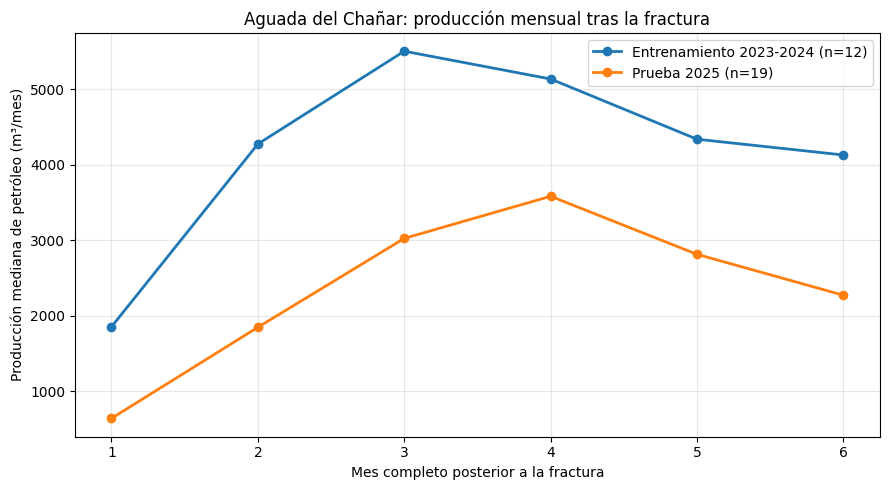


Tabla guardada: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/aguada_comparacion_produccion_mensual_ypf.csv
Gráfico guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/aguada_comparacion_produccion_mensual_ypf.png
PASO 14 COMPLETADO


In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CARPETA_DATOS = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)
CARPETA_PROCESADOS = CARPETA_DATOS.parent / "Datos_Procesados"

entrenamiento = pd.read_csv(
    CARPETA_PROCESADOS / "ypf_entrenamiento_6m.csv",
    dtype={"idpozo": "string"},
)
prueba = pd.read_csv(
    CARPETA_PROCESADOS / "ypf_prueba_6m.csv",
    dtype={"idpozo": "string"},
)
evaluacion = pd.read_csv(
    CARPETA_PROCESADOS / "evaluacion_ypf_2025_h1_por_pozo.csv",
    dtype={"idpozo": "string"},
)
produccion = pd.read_csv(
    CARPETA_PROCESADOS
    / "produccion_mensual_pozos_ypf_2023_2025.csv",
    dtype={"idpozo": "string"},
    usecols=["idpozo", "fecha_mes", "prod_pet"],
)

for nombre, tabla, columnas in [
    (
        "entrenamiento",
        entrenamiento,
        [
            "idpozo", "fecha_fin_fractura",
            "areapermisoconcesion", "produccion_6m_m3",
        ],
    ),
    (
        "prueba",
        prueba,
        [
            "idpozo", "fecha_fin_fractura",
            "areapermisoconcesion",
        ],
    ),
    (
        "evaluación",
        evaluacion,
        ["idpozo", "real_6m_m3"],
    ),
]:
    ausentes = [c for c in columnas if c not in tabla.columns]
    if ausentes:
        raise ValueError(f"Faltan columnas en {nombre}: {ausentes}")

    if tabla["idpozo"].duplicated().any():
        raise ValueError(f"Hay pozos repetidos en {nombre}.")

entrenamiento["areapermisoconcesion"] = (
    entrenamiento["areapermisoconcesion"]
    .astype(str).str.strip().str.upper()
)
prueba["areapermisoconcesion"] = (
    prueba["areapermisoconcesion"]
    .astype(str).str.strip().str.upper()
)

aguada_entrenamiento = entrenamiento.loc[
    entrenamiento["areapermisoconcesion"] == "AGUADA DEL CHAÑAR",
    ["idpozo", "fecha_fin_fractura", "produccion_6m_m3"],
].copy()
aguada_entrenamiento = aguada_entrenamiento.rename(
    columns={"produccion_6m_m3": "objetivo_6m_m3"}
)
aguada_entrenamiento["cohorte"] = "Entrenamiento 2023-2024"

aguada_prueba = prueba.loc[
    prueba["areapermisoconcesion"] == "AGUADA DEL CHAÑAR",
    ["idpozo", "fecha_fin_fractura"],
].copy()
aguada_prueba = aguada_prueba.merge(
    evaluacion[["idpozo", "real_6m_m3"]],
    on="idpozo",
    how="left",
    validate="one_to_one",
)
aguada_prueba = aguada_prueba.rename(
    columns={"real_6m_m3": "objetivo_6m_m3"}
)
aguada_prueba["cohorte"] = "Prueba 2025"

pozos = pd.concat(
    [aguada_entrenamiento, aguada_prueba],
    ignore_index=True,
)

if len(aguada_entrenamiento) != 12 or len(aguada_prueba) != 19:
    raise ValueError(
        "La cantidad de pozos de Aguada no coincide con el paso 13."
    )
if pozos["objetivo_6m_m3"].isna().any():
    raise ValueError("Hay objetivos faltantes para pozos de Aguada.")

pozos["fecha_fin_fractura"] = pd.to_datetime(
    pozos["fecha_fin_fractura"], errors="raise"
)
pozos["objetivo_6m_m3"] = pd.to_numeric(
    pozos["objetivo_6m_m3"], errors="raise"
)

produccion["fecha_mes"] = (
    pd.to_datetime(produccion["fecha_mes"], errors="raise")
    .dt.to_period("M")
    .dt.to_timestamp()
)
produccion["prod_pet"] = pd.to_numeric(
    produccion["prod_pet"], errors="raise"
)

if produccion.duplicated(["idpozo", "fecha_mes"]).any():
    raise ValueError(
        "Hay registros duplicados para un mismo pozo y mes."
    )

# Seis meses completos posteriores al mes de finalización.
meses = pd.DataFrame({"mes_post_fractura": [1, 2, 3, 4, 5, 6]})
calendario = pozos.merge(meses, how="cross")

mes_base = (
    calendario["fecha_fin_fractura"].dt.year * 12
    + calendario["fecha_fin_fractura"].dt.month - 1
)
mes_objetivo = mes_base + calendario["mes_post_fractura"]

calendario["fecha_mes"] = pd.to_datetime(
    {
        "year": mes_objetivo // 12,
        "month": mes_objetivo % 12 + 1,
        "day": 1,
    }
)

calendario = calendario.merge(
    produccion[["idpozo", "fecha_mes", "prod_pet"]],
    on=["idpozo", "fecha_mes"],
    how="left",
    validate="one_to_one",
    indicator=True,
)

sin_registro = calendario["_merge"].ne("both").sum()
if sin_registro:
    raise ValueError(
        f"Se encontraron {sin_registro} meses sin registro; "
        "revisar antes de comparar las curvas."
    )
calendario = calendario.drop(columns="_merge")

# Comprobamos que la reconstrucción mensual reproduce cada objetivo.
control = (
    calendario.groupby("idpozo", as_index=False)
    .agg(
        suma_mensual_m3=("prod_pet", "sum"),
        objetivo_6m_m3=("objetivo_6m_m3", "first"),
    )
)
control["diferencia_m3"] = (
    control["suma_mensual_m3"] - control["objetivo_6m_m3"]
)

max_diferencia = control["diferencia_m3"].abs().max()
print(
    "Diferencia máxima entre suma mensual y objetivo:",
    round(max_diferencia, 4),
    "m³",
)

if max_diferencia > 0.05:
    display(
        control.loc[
            control["diferencia_m3"].abs() > 0.05
        ].head(10)
    )
    raise ValueError(
        "La producción mensual no reproduce el objetivo "
        "de seis meses. Detener la comparación."
    )

resumen_mensual = (
    calendario.groupby(["cohorte", "mes_post_fractura"])
    .agg(
        pozos=("idpozo", "nunique"),
        produccion_media_m3=("prod_pet", "mean"),
        produccion_mediana_m3=("prod_pet", "median"),
        pozos_con_cero=("prod_pet", lambda x: int((x == 0).sum())),
    )
    .reset_index()
)

print("\nPRODUCCIÓN MENSUAL DE AGUADA DEL CHAÑAR")
display(resumen_mensual.round(2))

fig, ax = plt.subplots(figsize=(9, 5))

for cohorte, datos in resumen_mensual.groupby("cohorte"):
    ax.plot(
        datos["mes_post_fractura"],
        datos["produccion_mediana_m3"],
        marker="o",
        linewidth=2,
        label=f"{cohorte} (n={datos['pozos'].iloc[0]})",
    )

ax.set_title(
    "Aguada del Chañar: producción mensual tras la fractura"
)
ax.set_xlabel("Mes completo posterior a la fractura")
ax.set_ylabel("Producción mediana de petróleo (m³/mes)")
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

archivo_tabla = (
    CARPETA_PROCESADOS
    / "aguada_comparacion_produccion_mensual_ypf.csv"
)
archivo_grafico = (
    CARPETA_PROCESADOS
    / "aguada_comparacion_produccion_mensual_ypf.png"
)

resumen_mensual.to_csv(archivo_tabla, index=False)
fig.savefig(archivo_grafico, dpi=180, bbox_inches="tight")
plt.show()

print("\nTabla guardada:", archivo_tabla)
print("Gráfico guardado:", archivo_grafico)
print("PASO 14 COMPLETADO")

Concusion:

Paso 14 completado. El control dio 0,0 m³ de diferencia, así que la comparación mensual reproduce exactamente el objetivo de seis meses.
En Aguada del Chañar, la producción de los pozos de prueba fue menor en los seis meses. La brecha ya aparece en el primero: la mediana pasó de 1856 a 643 m³, y 4 de los 19 pozos de 2025 registraron cero ese mes. La suma de las producciones medias mensuales equivale aproximadamente a 25 294 m³ por pozo en entrenamiento frente a 13 926 m³ en prueba: una caída cercana al 45 %.
Para presentar el ejercicio, formularía el hallazgo así:
Los tres modelos se evaluaron con pozos de 2025 que no participaron en el entrenamiento. La regresión lineal mejoró el error global frente a la referencia, pero falló de forma sistemática en Aguada del Chañar: sobreestimó sus 19 pozos. El análisis mensual confirmó una producción inferior desde el primer mes y durante todo el período observado. El ranking logístico tampoco priorizó ninguno de los 16 casos de baja productividad de esa área.

Mi evaluación como proyecto de ML: el mayor aporte no es afirmar que ya podemos predecir con precisión cada pozo. Es mostrar, con datos y una prueba temporal, dónde funciona la estimación, dónde falla y por qué una métrica global puede ocultar un riesgo operativo. Eso constituye un caso convincente de monitoreo del desempeño de modelos para el sector petrolero.
No atribuiría la caída a la fracturación ni a una causa geológica concreta: las variables disponibles no permiten demostrarlo. Tampoco ajustaría ahora los modelos para «corregir» Aguada y volver a llamar validación a la misma prueba de 2025. El siguiente paso útil es cerrar el ejercicio con una lámina de resultados y limitaciones, usando las tablas y el gráfico que ya generaste.
